# Cell 1 — Notebook title

# GNN4EEG FACED 9-Class Emotion Classification — CROSS-9

### Dataset-first, exact-paper nested cross-validation, Kaggle-ready, checkpointed, and resumable

This notebook runs the paper's **cross-9** multi-class experiment using the authors' processed `FACED_dataset_9_labels.mat` file.

It performs:

- `K = 10` outer folds;
- `K' = 3` inner folds;
- hidden dimensions `{20, 40, 80}`;
- learning rates `{0.0001, 0.001, 0.01}`;
- epoch candidates `1–100`;
- L1/L2 regularization selected for cross-9;
- fresh outer-fold retraining after inner-fold selection;
- final testing on the untouched outer test partition;
- epoch-level checkpoints and automatic Kaggle resume.

Early stopping is disabled because the paper compares validation accuracy across all epoch candidates.


# Cell 2 — Exact paper protocol implemented in this notebook

## CROSS-9 experimental design

| Component | Cross-9 setting |
|---|---|
| Split type | Subject-independent |
| Outer folds | `K = 10` |
| Outer test subjects | folds 1–9: 12 each; fold 10: 15 |
| Inner folds | `K' = 3` |
| Inner validation subjects | 37 for outer folds 1–9; 36 for outer fold 10 |
| Subject overlap | none between train, validation, and test |
| L1/L2 | 0.005 / 0.005 |
| RGNN NodeDAT | enabled |

## Shared paper settings

- Models enabled: DGCNN, RGNN, and SparseDGCNN
- GNN layers: 2
- Dropout: 0.5
- Batch size: 256
- Hidden dimensions: 20, 40, 80
- Learning rates: 0.0001, 0.001, 0.01
- Maximum epochs: 100
- Selection metric: average inner-validation accuracy
- Final result: weighted aggregation across all ten outer test folds

HetEmotionNet is not included because the consolidated DE/LDS MAT file does not contain its required raw time-domain stream.


# Cell 3 — Kaggle input checklist

## First run

Add only this file through Kaggle **Add Input**:

```text
FACED_dataset_9_labels.mat
```

## Resumed run

Add:

```text
FACED_dataset_9_labels.mat
gnn4eeg_cross9_exact_ncv_resume_bundle.zip
```

The ZIP is generated by this notebook after training begins. It is not required for the first run.

Run this notebook only; the EDA notebook is not required as an input.


# Cell 4 — Execution roadmap

## Notebook sequence

1. Import every library in one place
2. Locate and load `FACED_dataset_9_labels.mat`
3. Display the raw dataset and convert it to graph samples
4. Show dataset information, nine-class labels, distributions, and quality checks
5. Explain the exact `K=10`, `K'=3`, and epoch 1–100 procedure
6. Configure and verify the exact paper experiment
7. Create or restore checkpoint folders
8. Apply subject-wise normalization
9. Construct and verify the exact outer and inner folds
10. Create PyTorch datasets and graph utilities
11. Define DGCNN
12. Define RGNN
13. Define SparseDGCNN
14. Run exact nested cross-validation with resumable checkpoints
15. Evaluate, visualize, and export results

Run the cells from top to bottom. Do not skip the dataset-validation or fold-verification cells.


> **Repair applied:** Portable CPU checkpoint loading, automatic full-workspace restore, `latest.pt` → `previous.pt` fallback, checkpoint compatibility validation, redundant inner-checkpoint pruning, periodic lightweight resume bundles, and emergency bundling on Python exceptions.

# Cell 5 — Section 1 start — All imports

# Section 1 — Import every required library

The next code cell is the **single import cell**. No later model section introduces hidden imports.


In [3]:
# Cell 6 — Import all libraries in one place

# Standard-library imports
import os
import gc
import json
import math
import time
import copy
import random
import shutil
import zipfile
import hashlib
import warnings
import importlib.util
from itertools import product, permutations
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Scientific-computing and notebook imports
import h5py
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Scikit-learn imports
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Optional loader for some MATLAB v7.3 files.
try:
    import hdf5storage
except ImportError:
    hdf5storage = None

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("All imports completed successfully.")


All imports completed successfully.


In [4]:
# Cell 7 — Verify package availability and versions

REQUIRED_MODULES = ["numpy", "pandas", "scipy", "h5py", "sklearn", "torch", "matplotlib"]
missing = [name for name in REQUIRED_MODULES if importlib.util.find_spec(name) is None]

if missing:
    raise ImportError(
        "Missing required modules: " + ", ".join(missing) +
        ". Kaggle normally provides these packages in its base image."
    )

version_table = pd.DataFrame({
    "component": ["Python runtime", "NumPy", "Pandas", "PyTorch", "CUDA available", "hdf5storage optional"],
    "value": [
        os.sys.version.split()[0],
        np.__version__,
        pd.__version__,
        torch.__version__,
        str(torch.cuda.is_available()),
        "available" if hdf5storage is not None else "not installed; scipy/h5py fallback will be used",
    ],
})
display(version_table)


,component,value
0,Python runtime,3.12.13
1,NumPy,2.0.2
2,Pandas,2.3.3
3,PyTorch,2.10.0+cu128
4,CUDA available,True
5,hdf5storage optional,not installed; scipy/h5py fallback will be used


# Cell 8 — Section 1 end — Imports complete

**Section 1 complete.** All libraries are visible at the beginning of the notebook.


# Cell 9 — Section 2 start — Load and inspect the dataset

# Section 2 — Load the FACED 9-class dataset first

Immediately after the imports, this section:

- searches Kaggle input folders for the processed 9-class MAT file;
- loads the authors' `de_lds` array;
- displays the file path, file size, MAT keys, raw shape, datatype, and memory;
- converts it to `(123, 840, 150)`;
- creates the exact nine-class labels;
- reshapes it to `(103320, 30, 5)` graph samples;
- checks missing values, infinity values, class coverage, and dimensions.

The fold construction and model configuration appear only after the dataset has been loaded and understood.


In [5]:
# Cell 10 — Define dataset constants and locate the processed 9-class MAT file

# These constants are only for loading and validating the dataset.
# The complete experiment configuration is defined after the dataset section.
DATA_PATH_OVERRIDE = None
MAT_KEY_REQUESTED = "de_lds"
EXPECTED_SUBJECTS = 123
EXPECTED_SAMPLES_PER_SUBJECT = 840
NUM_CLASSES = 9
NUM_NODES = 30
NUM_FEATURES = 5

def discover_data_path(explicit_path: Optional[str] = None) -> Path:
    if explicit_path:
        path = Path(explicit_path)
        if path.exists():
            return path
        raise FileNotFoundError(f"Configured data path does not exist: {path}")

    search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd()]
    preferred_names = [
        "FACED_dataset_9_labels.mat",
        "faced_dataset_9_labels.mat",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for name in preferred_names:
            matches = list(root.rglob(name))
            if matches:
                return matches[0]

    for root in search_roots:
        if root.exists():
            matches = [
                path for path in root.rglob("*.mat")
                if "faced" in path.name.lower() and "9" in path.name
            ]
            if matches:
                return matches[0]

    raise FileNotFoundError(
        "Could not find FACED_dataset_9_labels.mat. "
        "Attach it through Kaggle's Add Input panel or set DATA_PATH_OVERRIDE."
    )

DATA_PATH = discover_data_path(DATA_PATH_OVERRIDE)
print("Dataset found:", DATA_PATH)


Dataset found: /kaggle/input/datasets/shairin006/faced-9-lables/FACED_dataset_9_labels.mat


In [6]:
# Check all Kaggle inputs and locate resume bundle/checkpoints

from pathlib import Path

print("=== Kaggle Input Structure ===")

for p in Path("/kaggle/input").rglob("*"):
    if p.is_file():
        print(p)

print("\n=== Searching for resume folder ===")

matches = []

for p in Path("/kaggle/input").rglob("gnn4eeg_cross9_exact_ncv"):
    matches.append(p)

if matches:
    for m in matches:
        print("FOUND:", m)
else:
    print("Resume folder not found")

print("\n=== Searching for checkpoint files ===")

checkpoints = list(Path("/kaggle/input").rglob("*.pt"))

print("Number of .pt files:", len(checkpoints))

for c in checkpoints[:20]:
    print(c)

=== Kaggle Input Structure ===
/kaggle/input/datasets/shairin006/faced-9-lables/FACED_dataset_9_labels.mat
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/resume_manifest.json
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_00/final/latest.pt
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_08/final/latest.pt
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_04/final/latest.pt
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_09/inner/hidden_20_lr_1e-03/fold_00/previous.pt
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_09/inner/hidden_20_lr_1e-03/fold_00/latest.pt
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn

In [7]:
# Cell 12 — Discover resume workspaces without account-specific paths

INPUT_ROOT = Path("/kaggle/input")
resume_workspace_names = {"gnn4eeg_cross9_exact_ncv"}
resume_candidates = []

if INPUT_ROOT.exists():
    for candidate in INPUT_ROOT.rglob("gnn4eeg_cross9_exact_ncv"):
        if candidate.is_dir() and (
            (candidate / "checkpoints").exists()
            or (candidate / "results").exists()
        ):
            resume_candidates.append(candidate)

print(f"Direct resume workspace candidates: {len(resume_candidates)}")
for candidate in resume_candidates[:10]:
    print(candidate)


Direct resume workspace candidates: 1
/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv


In [8]:
# Cell 13 — Discover resume ZIP files automatically

resume_zip_candidates = []
if INPUT_ROOT.exists():
    resume_zip_candidates = [
        path for path in INPUT_ROOT.rglob("*.zip")
        if "resume" in path.name.lower() or "exact_ncv" in path.name.lower()
    ]

print(f"Resume ZIP candidates: {len(resume_zip_candidates)}")
for candidate in resume_zip_candidates[:10]:
    print(candidate)


Resume ZIP candidates: 0


In [9]:
# Cell 14 — Automatic restoration is performed after WORK_ROOT is created
print("Checkpoint paths do not need to be entered manually. The notebook will discover and merge the most advanced attached resume bundle automatically.")


Checkpoint paths do not need to be entered manually. The notebook will discover and merge the most advanced attached resume bundle automatically.


In [10]:
# Cell 11 — Load the MATLAB file robustly

def load_mat_array(path: Path, preferred_key: str = "de_lds") -> Tuple[np.ndarray, str, List[str]]:
    """Load a numeric MATLAB array through hdf5storage, scipy, or h5py."""
    data_dict = None
    errors = []

    if hdf5storage is not None:
        try:
            data_dict = hdf5storage.loadmat(str(path))
        except Exception as exc:
            errors.append(f"hdf5storage: {exc}")

    if data_dict is None:
        try:
            data_dict = sio.loadmat(str(path))
        except Exception as exc:
            errors.append(f"scipy.io.loadmat: {exc}")

    if data_dict is None:
        try:
            with h5py.File(path, "r") as handle:
                data_dict = {key: np.array(handle[key]) for key in handle.keys()}
        except Exception as exc:
            errors.append(f"h5py: {exc}")

    if data_dict is None:
        raise RuntimeError("Unable to read the MAT file. " + " | ".join(errors))

    candidate_keys = [key for key in data_dict.keys() if not key.startswith("__")]
    if not candidate_keys:
        raise KeyError("The MAT file contains no visible data keys.")

    if preferred_key in data_dict:
        return np.asarray(data_dict[preferred_key]), preferred_key, candidate_keys

    numeric_candidates = []
    for key in candidate_keys:
        value = np.asarray(data_dict[key])
        if np.issubdtype(value.dtype, np.number) and value.ndim >= 2:
            numeric_candidates.append((value.size, key, value))

    if not numeric_candidates:
        raise KeyError(
            f"No numeric array was found. Preferred key: '{preferred_key}'. "
            f"Available keys: {candidate_keys}"
        )

    _, selected_key, selected_array = max(numeric_candidates, key=lambda item: item[0])
    print(f"Preferred key '{preferred_key}' was not found; using largest numeric array: {selected_key}")
    return selected_array, selected_key, candidate_keys

raw_array, MAT_KEY_USED, MAT_KEYS = load_mat_array(DATA_PATH, MAT_KEY_REQUESTED)
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [11]:
# Cell 12 — Display the loaded file and raw array information

file_size_mb = DATA_PATH.stat().st_size / (1024 ** 2)

raw_information = pd.DataFrame({
    "property": [
        "Dataset path",
        "File name",
        "File size (MB)",
        "Available MAT keys",
        "Selected MAT key",
        "Raw array shape",
        "Raw datatype",
        "Raw dimensions",
        "Raw element count",
        "Raw memory (MB)",
    ],
    "value": [
        str(DATA_PATH),
        DATA_PATH.name,
        f"{file_size_mb:.3f}",
        ", ".join(MAT_KEYS),
        MAT_KEY_USED,
        str(tuple(raw_array.shape)),
        str(raw_array.dtype),
        int(raw_array.ndim),
        f"{raw_array.size:,}",
        f"{raw_array.nbytes / (1024 ** 2):.3f}",
    ],
})

display(raw_information)


,property,value
0,Dataset path,/kaggle/input/datasets/shairin006/faced-9-labl...
1,File name,FACED_dataset_9_labels.mat
2,File size (MB),118.241
3,Available MAT keys,de_lds
4,Selected MAT key,de_lds
5,Raw array shape,"(123, 840, 150)"
6,Raw datatype,float64
7,Raw dimensions,3
8,Raw element count,"15,498,000"
9,Raw memory (MB),118.240


In [12]:
# Cell 13 — Convert the array to canonical shape (123, 840, 150)
def canonicalize_faced_shape(array: np.ndarray) -> np.ndarray:
    array = np.squeeze(array)

    if array.ndim == 3:
        target = (123, 840, 150)
        if array.shape == target:
            return array.astype(np.float32, copy=False)

        # MATLAB/HDF5 readers may reverse axis order.
        for perm in permutations(range(3)):
            candidate = np.transpose(array, perm)
            if candidate.shape == target:
                return candidate.astype(np.float32, copy=False)

    if array.ndim == 4:
        # Also accept model-ready layouts containing explicit node/band axes.
        possible = [
            (123, 840, 30, 5),
            (123, 30, 840, 5),
            (123, 840, 5, 30),
        ]
        if array.shape in possible:
            if array.shape == (123, 30, 840, 5):
                array = array.transpose(0, 2, 1, 3)
            elif array.shape == (123, 840, 5, 30):
                array = array.transpose(0, 1, 3, 2)
            return array.reshape(123, 840, 150).astype(np.float32, copy=False)

    raise ValueError(
        f"Unexpected FACED shape {array.shape}. Expected a permutation of (123, 840, 150), "
        "or a compatible 4D representation."
    )

subject_sample_features = canonicalize_faced_shape(raw_array)
print("Canonical shape:", subject_sample_features.shape)


Canonical shape: (123, 840, 150)


In [13]:
# Cell 14 — Create the exact nine emotion labels and sample metadata
EMOTION_NAMES = [
    "Anger", "Disgust", "Fear", "Sadness", "Neutral",
    "Amusement", "Inspiration", "Joy", "Tenderness"
]

# Zero-based videos 0..27. Neutral has four videos; all other classes have three.
VIDEO_TO_CLASS = np.array(
    [0]*3 + [1]*3 + [2]*3 + [3]*3 + [4]*4 + [5]*3 + [6]*3 + [7]*3 + [8]*3,
    dtype=np.int64,
)
assert len(VIDEO_TO_CLASS) == 28

labels_one_subject = np.repeat(VIDEO_TO_CLASS, 30)
video_ids_one_subject = np.repeat(np.arange(28, dtype=np.int64), 30)
second_ids_one_subject = np.tile(np.arange(30, dtype=np.int64), 28)

NUM_SUBJECTS = subject_sample_features.shape[0]
SAMPLES_PER_SUBJECT = subject_sample_features.shape[1]
assert SAMPLES_PER_SUBJECT == 840

labels = np.tile(labels_one_subject, NUM_SUBJECTS)
subject_ids = np.repeat(np.arange(NUM_SUBJECTS, dtype=np.int64), SAMPLES_PER_SUBJECT)
video_ids = np.tile(video_ids_one_subject, NUM_SUBJECTS)
second_ids = np.tile(second_ids_one_subject, NUM_SUBJECTS)

print("Labels:", labels.shape)
print("Subjects:", subject_ids.shape)
print("Videos:", video_ids.shape)
print("Seconds:", second_ids.shape)


Labels: (103320,)
Subjects: (103320,)
Videos: (103320,)
Seconds: (103320,)


In [14]:
# Cell 15 — Reshape the data into graph samples
# Important: preserve individual one-second observations.
# Do not train on EDA-level subject-emotion averages or channel summary tables.
X = subject_sample_features.reshape(-1, NUM_NODES, NUM_FEATURES).astype(np.float32, copy=False)
y = labels.astype(np.int64, copy=False)

print("Graph input shape:", X.shape)
print("Target shape:", y.shape)
print("Expected model input: [samples, 30 nodes, 5 DE bands]")


Graph input shape: (103320, 30, 5)
Target shape: (103320,)
Expected model input: [samples, 30 nodes, 5 DE bands]


In [15]:
# Cell 16 — Run strict structural and numerical checks
assert X.shape == (103_320, 30, 5), X.shape
assert y.shape == (103_320,), y.shape
assert subject_ids.shape == y.shape
assert video_ids.shape == y.shape
assert second_ids.shape == y.shape
assert np.isfinite(X).all(), "Data contain NaN or infinite values."
assert set(np.unique(y)) == set(range(9))
assert subject_ids.min() == 0 and subject_ids.max() == 122
assert second_ids.min() == 0 and second_ids.max() == 29

print("All structural and numerical checks passed.")


All structural and numerical checks passed.


In [16]:
# Cell 17 — Display a complete model-ready dataset summary

CHANNEL_NAMES_30 = [
    "Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FC1", "FC2", "FC5",
    "FC6", "Cz", "C3", "C4", "T7", "T8", "CP1", "CP2", "CP5", "CP6",
    "Pz", "P3", "P4", "P7", "P8", "PO3", "PO4", "Oz", "O1", "O2",
]
BAND_NAMES = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

dataset_summary = pd.DataFrame({
    "dataset property": [
        "Participants",
        "Videos per participant",
        "One-second windows per video",
        "Samples per participant",
        "Total graph samples",
        "Graph nodes",
        "Node features",
        "Emotion classes",
        "Model-ready shape",
        "Target shape",
        "Feature datatype",
        "Target datatype",
        "Finite values",
        "Missing values",
        "Infinite values",
    ],
    "value": [
        int(np.unique(subject_ids).size),
        28,
        30,
        int(SAMPLES_PER_SUBJECT),
        int(X.shape[0]),
        int(X.shape[1]),
        int(X.shape[2]),
        int(np.unique(y).size),
        str(tuple(X.shape)),
        str(tuple(y.shape)),
        str(X.dtype),
        str(y.dtype),
        bool(np.isfinite(X).all()),
        int(np.isnan(X).sum()),
        int(np.isinf(X).sum()),
    ],
})
display(dataset_summary)


,dataset property,value
0,Participants,123
1,Videos per participant,28
2,One-second windows per video,30
3,Samples per participant,840
4,Total graph samples,103320
5,Graph nodes,30
6,Node features,5
7,Emotion classes,9
8,Model-ready shape,"(103320, 30, 5)"
9,Target shape,"(103320,)"


In [17]:
# Cell 18 — Display the nine classes and their sample counts

class_counts = np.bincount(y, minlength=9)
class_summary = pd.DataFrame({
    "class_id": np.arange(9),
    "emotion": EMOTION_NAMES,
    "videos_per_subject": [3, 3, 3, 3, 4, 3, 3, 3, 3],
    "samples_per_subject": [90, 90, 90, 90, 120, 90, 90, 90, 90],
    "total_samples": class_counts,
    "percentage": class_counts / class_counts.sum() * 100,
})

display(class_summary.style.format({"percentage": "{:.2f}%"}))
print("Total samples:", f"{class_counts.sum():,}")
print("Chance-level accuracy for nine balanced classes:", f"{1/9:.2%}")


,class_id,emotion,videos_per_subject,samples_per_subject,total_samples,percentage
0,0,Anger,3,90,11070,10.71%
1,1,Disgust,3,90,11070,10.71%
2,2,Fear,3,90,11070,10.71%
3,3,Sadness,3,90,11070,10.71%
4,4,Neutral,4,120,14760,14.29%
5,5,Amusement,3,90,11070,10.71%
6,6,Inspiration,3,90,11070,10.71%
7,7,Joy,3,90,11070,10.71%
8,8,Tenderness,3,90,11070,10.71%


Total samples: 103,320
Chance-level accuracy for nine balanced classes: 11.11%


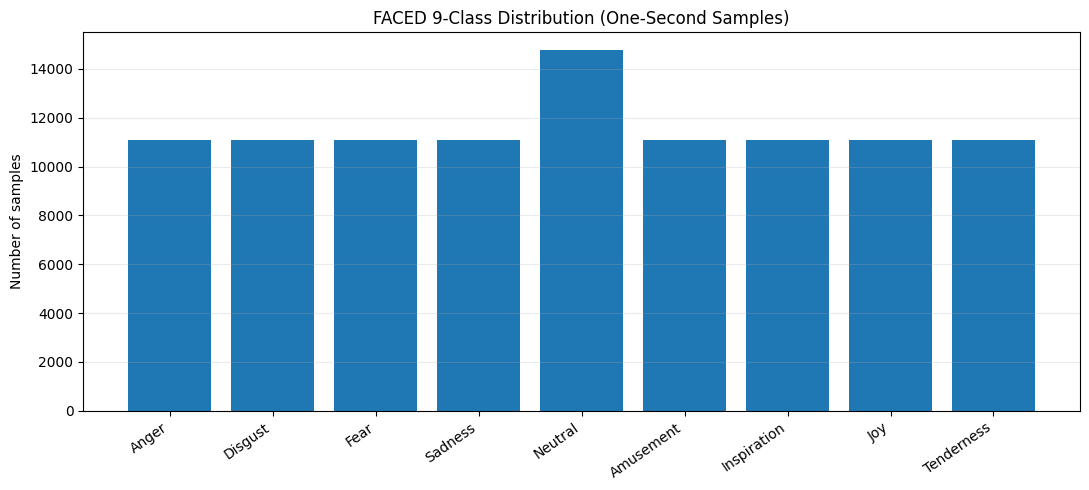

In [18]:
# Cell 19 — Plot the nine-class sample distribution
plt.figure(figsize=(11, 5))
plt.bar(class_summary["emotion"], class_summary["total_samples"])
plt.title("FACED 9-Class Distribution (One-Second Samples)")
plt.ylabel("Number of samples")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [19]:
# Cell 20 — Display descriptive statistics for the five DE bands

node_band_view = X.reshape(-1, NUM_FEATURES)

band_summary = pd.DataFrame({
    "band": BAND_NAMES,
    "mean": node_band_view.mean(axis=0),
    "standard_deviation": node_band_view.std(axis=0),
    "minimum": node_band_view.min(axis=0),
    "maximum": node_band_view.max(axis=0),
    "median": np.median(node_band_view, axis=0),
})

display(
    band_summary.style.format({
        "mean": "{:.5f}",
        "standard_deviation": "{:.5f}",
        "minimum": "{:.5f}",
        "maximum": "{:.5f}",
        "median": "{:.5f}",
    })
)


,band,mean,standard_deviation,minimum,maximum,median
0,Delta,0.01137,0.33636,-1.80448,8.13206,-0.00605
1,Theta,0.01581,0.33673,-2.03553,8.19349,-0.00386
2,Alpha,0.00942,0.32682,-1.63415,8.07680,-0.00827
3,Beta,0.01086,0.32261,-1.44000,7.39443,-0.00555
4,Gamma,0.01183,0.32532,-1.58377,7.49801,-0.00500


In [20]:
# Cell 21 — Preview one complete graph sample

preview_sample_index = 0
preview_subject = int(subject_ids[preview_sample_index])
preview_video = int(video_ids[preview_sample_index])
preview_second = int(second_ids[preview_sample_index])
preview_class = int(y[preview_sample_index])

print(
    f"Sample index: {preview_sample_index} | "
    f"subject: {preview_subject} | video: {preview_video} | second: {preview_second} | "
    f"class: {preview_class} ({EMOTION_NAMES[preview_class]})"
)

sample_graph_frame = pd.DataFrame(
    X[preview_sample_index],
    index=CHANNEL_NAMES_30,
    columns=BAND_NAMES,
)
sample_graph_frame.index.name = "EEG_channel"
display(sample_graph_frame)


Sample index: 0 | subject: 0 | video: 0 | second: 0 | class: 0 (Anger)


,Delta,Theta,Alpha,Beta,Gamma
EEG_channel,,,,,
Fp1,-0.141803,-0.180997,0.019299,0.068933,-0.011574
Fp2,0.034672,0.011088,0.035323,-0.046050,0.028410
Fz,0.038618,-0.090639,-0.018089,0.029610,0.054402
F3,0.028235,-0.048940,-0.106100,-0.012332,0.011910
F4,-0.094086,-0.086844,-0.063449,-0.062360,-0.022250
F7,-0.099169,-0.094877,-0.011549,-0.063426,-0.032992
F8,-0.176173,-0.178124,0.147411,0.203082,0.086235
FC1,0.052171,0.027430,0.129424,0.095848,0.086460
FC2,0.096964,0.051922,0.014632,0.043846,0.095887


# Cell 22 — Interpret the loaded dataset

## What has been loaded

The notebook is now using the authors' processed **9-class FACED differential-entropy dataset**, not the EDA summary tables.

- Raw canonical data: `123 × 840 × 150`
- Participants: 123
- Samples per participant: `28 videos × 30 one-second windows = 840`
- Features per sample: `30 scalp channels × 5 DE bands = 150`
- Model-ready graph data: `103320 × 30 × 5`
- Targets: nine integer class IDs from 0 to 8
- The final two ocular channels are not part of the 30-node graph representation.
- Neutral has four videos; every other emotion has three videos.

Training will preserve every one-second observation. It will not use the EDA notebook's subject-emotion averages or channel-summary rows.


# Cell 23 — Section 2 end — Dataset loaded and understood

**Section 2 complete.** The dataset has been physically loaded, validated, reshaped, labeled, summarized, and previewed before any fold construction or model training.


# Cell 24 — Exact folds and epochs explained before training

# Section 3 — Cross-9 folds, epochs, and configuration

## Outer folds: K = 10

The 123 participants are divided exactly as stated in the paper:

```text
12, 12, 12, 12, 12, 12, 12, 12, 12, 15 test subjects
```

## Inner folds: K' = 3

- Outer folds 1–9: 111 outer train+validation subjects, divided into three 37-subject validation folds.
- Outer fold 10: 108 outer train+validation subjects, divided into three 36-subject validation folds.

No subject appears in training, validation, and testing at the same time.

## Epoch selection

For every model, hidden dimension, and learning rate, all three inner models produce validation accuracy for epochs 1–100. The epoch and hyperparameters with the best average inner-validation accuracy are selected. A fresh model is then trained on the entire outer train+validation partition and evaluated on the untouched outer test subjects.


In [21]:
# Cell 25 — Display the cross-9 fold and epoch plan

plan = pd.DataFrame({
    "item": [
        "Task", "Outer folds", "Inner folds", "Outer test-subject pattern",
        "Inner validation subjects", "Models", "Hidden dimensions",
        "Learning rates", "Epoch candidates", "L1/L2", "Early stopping",
        "Checkpoint frequency",
    ],
    "value": [
        "cross-9", "K = 10", "K' = 3", "12×9 folds + 15×1 fold",
        "37 for folds 1–9; 36 for fold 10",
        "DGCNN, RGNN, SparseDGCNN", "{20, 40, 80}",
        "{0.0001, 0.001, 0.01}", "1–100", "0.005 / 0.005",
        "Disabled", "Every epoch",
    ],
})
display(plan)


,item,value
0,Task,cross-9
1,Outer folds,K = 10
2,Inner folds,K' = 3
3,Outer test-subject pattern,12×9 folds + 15×1 fold
4,Inner validation subjects,37 for folds 1–9; 36 for fold 10
5,Models,"DGCNN, RGNN, SparseDGCNN"
6,Hidden dimensions,"{20, 40, 80}"
7,Learning rates,"{0.0001, 0.001, 0.01}"
8,Epoch candidates,1–100
9,L1/L2,0.005 / 0.005


# Cell 26 — Section 3 continued — Define the exact experiment configuration

The dataset is already loaded. This subsection now fixes the task, models, folds, hyperparameter grid, epoch limit, regularization, and checkpoint behavior.


In [22]:
# Cell 27 — Define the exact-paper experiment configuration
ALLOWED_MODELS = {"DGCNN", "RGNN", "SparseDGCNN"}
MODEL_SEED_OFFSETS = {"DGCNN": 0, "RGNN": 1_000_000, "SparseDGCNN": 2_000_000}

@dataclass
class Config:
    # Loaded data
    data_path: str = str(DATA_PATH)
    mat_key: str = MAT_KEY_USED
    protocol: str = "cross_subject"   # fixed for cross-9
    apply_subject_zscore: bool = True

    # Models: choose any subset of ["DGCNN", "RGNN", "SparseDGCNN"]
    # All DE-based GNN models are enabled for the complete cross-9 run.
    models_to_run: Tuple[str, ...] = ("DGCNN", "RGNN", "SparseDGCNN")
    rgnn_node_dat: bool = True

    # Fixed architecture/training settings from the paper
    num_classes: int = NUM_CLASSES
    num_nodes: int = NUM_NODES
    num_features: int = NUM_FEATURES
    gnn_layers: int = 2
    dropout: float = 0.5
    batch_size: int = 256
    max_epochs: int = 100
    gradient_clip: float = 20.0
    num_workers: int = 2
    mixed_precision: bool = True

    # Exact paper hyperparameter search
    hidden_dimensions: Tuple[int, ...] = (20, 40, 80)
    learning_rates: Tuple[float, ...] = (1e-4, 1e-3, 1e-2)
    outer_folds: int = 10
    inner_folds: int = 3
    selection_metric: str = "accuracy"

    # Exactness switches
    exact_paper_ncv: bool = True
    use_early_stopping: bool = False
    folds_to_run: Optional[Tuple[int, ...]] = None  # None = all ten outer folds

    # Checkpoint and resume
    resume: bool = True
    save_every_epoch: bool = True
    refresh_bundle_every_n_epochs: int = 25
    work_root: str = "/kaggle/working/gnn4eeg_cross9_exact_ncv"
    checkpoint_input_search: str = "/kaggle/input"

    # Debug controls: keep both None for final paper-aligned results.
    debug_max_epochs: Optional[int] = None
    debug_hyperparameter_limit: Optional[int] = None

    @property
    def l1_reg(self) -> float:
        return 0.005 if self.protocol == "cross_subject" else 0.003

    @property
    def l2_reg(self) -> float:
        return 0.005 if self.protocol == "cross_subject" else 0.003

    @property
    def effective_max_epochs(self) -> int:
        return self.max_epochs if self.debug_max_epochs is None else int(self.debug_max_epochs)

CFG = Config()
CFG


Config(data_path='/kaggle/input/datasets/shairin006/faced-9-lables/FACED_dataset_9_labels.mat', mat_key='de_lds', protocol='cross_subject', apply_subject_zscore=True, models_to_run=('DGCNN', 'RGNN', 'SparseDGCNN'), rgnn_node_dat=True, num_classes=9, num_nodes=30, num_features=5, gnn_layers=2, dropout=0.5, batch_size=256, max_epochs=100, gradient_clip=20.0, num_workers=2, mixed_precision=True, hidden_dimensions=(20, 40, 80), learning_rates=(0.0001, 0.001, 0.01), outer_folds=10, inner_folds=3, selection_metric='accuracy', exact_paper_ncv=True, use_early_stopping=False, folds_to_run=None, resume=True, save_every_epoch=True, refresh_bundle_every_n_epochs=25, work_root='/kaggle/working/gnn4eeg_cross9_exact_ncv', checkpoint_input_search='/kaggle/input', debug_max_epochs=None, debug_hyperparameter_limit=None)

In [23]:
# Cell 28 — Validate and display the exact-paper configuration
assert CFG.protocol == "cross_subject"
assert set(CFG.models_to_run) == ALLOWED_MODELS
assert set(MODEL_SEED_OFFSETS) == ALLOWED_MODELS
assert CFG.num_classes == 9
assert CFG.num_nodes == 30
assert CFG.num_features == 5
assert CFG.outer_folds == 10
assert CFG.inner_folds == 3
assert CFG.max_epochs == 100
assert CFG.hidden_dimensions == (20, 40, 80)
assert CFG.learning_rates == (1e-4, 1e-3, 1e-2)
assert CFG.selection_metric == "accuracy"
assert CFG.exact_paper_ncv is True
assert CFG.use_early_stopping is False, "Early stopping changes the exact paper NCV epoch-selection procedure."

configuration_table = pd.DataFrame(
    [{"parameter": key, "selected_value": value} for key, value in asdict(CFG).items()]
)
display(configuration_table)

print("Selected task: cross-9")
print(f"Task regularization: L1={CFG.l1_reg}, L2={CFG.l2_reg}")
print(f"Outer folds K={CFG.outer_folds}; inner folds K'={CFG.inner_folds}")
print(f"Epoch candidates: 1–{CFG.effective_max_epochs}")
print("Early stopping: OFF (required for exact epoch selection); checkpoint resume: ON")


,parameter,selected_value
0,data_path,/kaggle/input/datasets/shairin006/faced-9-labl...
1,mat_key,de_lds
2,protocol,cross_subject
3,apply_subject_zscore,True
4,models_to_run,"(DGCNN, RGNN, SparseDGCNN)"
5,rgnn_node_dat,True
6,num_classes,9
7,num_nodes,30
8,num_features,5
9,gnn_layers,2


Selected task: cross-9
Task regularization: L1=0.005, L2=0.005
Outer folds K=10; inner folds K'=3
Epoch candidates: 1–100
Early stopping: OFF (required for exact epoch selection); checkpoint resume: ON


In [24]:
# Cell 29 — Set reproducibility and select the device
def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


# Cell 30 — Section 3 end — Folds, epochs, and configuration ready

**Section 3 complete.** The notebook has explained and configured exact `K=10`, `K'=3`, epochs 1–100, the full 9-combination grid, task-specific regularization, and epoch-level resume checkpoints.


# Cell 31 — Section 4 start — Checkpoint workspace and restoration

# Section 4 — Create output folders and restore checkpoints

The dataset has already been loaded and displayed. The notebook now prepares the resumable training workspace.


In [25]:
# Cell 32 — Validate paths and create checkpoint/result folders

WORK_ROOT = Path(CFG.work_root)
CHECKPOINT_ROOT = WORK_ROOT / "checkpoints"
RESULTS_ROOT = WORK_ROOT / "results"
EXPORT_ROOT = WORK_ROOT / "exports"

for folder in [WORK_ROOT, CHECKPOINT_ROOT, RESULTS_ROOT, EXPORT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

path_table = pd.DataFrame({
    "purpose": ["Working root", "Checkpoints", "Results", "Exports"],
    "path": [str(WORK_ROOT), str(CHECKPOINT_ROOT), str(RESULTS_ROOT), str(EXPORT_ROOT)],
})
display(path_table)


,purpose,path
0,Working root,/kaggle/working/gnn4eeg_cross9_exact_ncv
1,Checkpoints,/kaggle/working/gnn4eeg_cross9_exact_ncv/check...
2,Results,/kaggle/working/gnn4eeg_cross9_exact_ncv/results
3,Exports,/kaggle/working/gnn4eeg_cross9_exact_ncv/exports


In [26]:
# Cell 33 — Automatically discover and restore the most advanced resume workspace

AUTO_RESUME_EXTRACT_ROOT = WORK_ROOT.parent / "_auto_resume_sources"
AUTO_RESUME_EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)


def _torch_load_cpu_compat(path: Path):
    """Load a checkpoint on CPU so non-model tensors such as RNG states stay portable."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _checkpoint_epoch(path: Path) -> int:
    try:
        state = _torch_load_cpu_compat(path)
        return int(state.get("epoch", -1)) if isinstance(state, dict) else -1
    except Exception:
        return -1


def _history_row_count(path: Path) -> int:
    try:
        return int(len(pd.read_csv(path)))
    except Exception:
        return -1


def _valid_json(path: Path) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as handle:
            json.load(handle)
        return True
    except Exception:
        return False


def _safe_extract_zip(zip_path: Path, destination: Path) -> None:
    """Extract a ZIP while rejecting path-traversal members."""
    destination.mkdir(parents=True, exist_ok=True)
    destination_resolved = destination.resolve()
    with zipfile.ZipFile(zip_path, "r") as archive:
        for member in archive.infolist():
            member_target = (destination / member.filename).resolve()
            if destination_resolved not in member_target.parents and member_target != destination_resolved:
                raise ValueError(f"Unsafe ZIP member rejected: {member.filename}")
        archive.extractall(destination)


def _resume_progress_score(root: Path) -> Tuple[int, int, int, int]:
    results = root / "results"
    checkpoints = root / "checkpoints"
    completed_count = len(list(results.rglob("completed.json"))) if results.exists() else 0
    history_rows = sum(
        max(0, _history_row_count(path))
        for path in results.rglob("history.csv")
    ) if results.exists() else 0
    checkpoint_epochs = sum(
        max(0, _checkpoint_epoch(path) + 1)
        for path in checkpoints.rglob("latest.pt")
    ) if checkpoints.exists() else 0
    file_count = sum(1 for path in root.rglob("*") if path.is_file())
    return completed_count, history_rows, checkpoint_epochs, file_count


def discover_resume_roots(search_root: Path) -> List[Path]:
    roots = set()
    if not search_root.exists():
        return []

    # Kaggle may expose an already-extracted dataset folder.
    for candidate in search_root.rglob(WORK_ROOT.name):
        if candidate.is_dir() and (
            (candidate / "checkpoints").exists()
            or (candidate / "results").exists()
        ):
            roots.add(candidate.resolve())

    # It may instead expose the downloaded resume ZIP itself.
    zip_candidates = [
        path for path in search_root.rglob("*.zip")
        if "resume" in path.name.lower() or "exact_ncv" in path.name.lower()
    ]
    for zip_path in zip_candidates:
        extraction_key = hashlib.sha256(str(zip_path).encode("utf-8")).hexdigest()[:12]
        extraction_dir = AUTO_RESUME_EXTRACT_ROOT / extraction_key
        marker = extraction_dir / ".extracted_ok"
        if not marker.exists():
            if extraction_dir.exists():
                shutil.rmtree(extraction_dir)
            _safe_extract_zip(zip_path, extraction_dir)
            marker.touch()

        for candidate in extraction_dir.rglob(WORK_ROOT.name):
            if candidate.is_dir() and (
                (candidate / "checkpoints").exists()
                or (candidate / "results").exists()
            ):
                roots.add(candidate.resolve())

    return sorted(roots)


def _source_is_better(source: Path, destination: Path) -> bool:
    if not destination.exists():
        return True

    if source.suffix == ".pt":
        source_epoch = _checkpoint_epoch(source)
        destination_epoch = _checkpoint_epoch(destination)
        return source_epoch > destination_epoch

    if source.name == "history.csv":
        return _history_row_count(source) > _history_row_count(destination)

    if source.name in {"completed.json", "selected_configuration.json"}:
        return _valid_json(source) and not _valid_json(destination)

    if destination.stat().st_size == 0 and source.stat().st_size > 0:
        return True

    return False


def merge_resume_workspace(source_root: Path, destination_root: Path) -> Dict[str, int]:
    copied = 0
    replaced = 0
    skipped = 0

    for source in source_root.rglob("*"):
        if not source.is_file():
            continue
        relative = source.relative_to(source_root)
        destination = destination_root / relative
        destination.parent.mkdir(parents=True, exist_ok=True)

        if not destination.exists():
            shutil.copy2(source, destination)
            copied += 1
        elif _source_is_better(source, destination):
            shutil.copy2(source, destination)
            replaced += 1
        else:
            skipped += 1

    return {"copied": copied, "replaced": replaced, "skipped": skipped}


def prune_completed_inner_checkpoints() -> int:
    """Completed inner runs need their history/results, not their large optimizer checkpoints."""
    removed = 0
    if not CHECKPOINT_ROOT.exists():
        return removed

    for latest_path in CHECKPOINT_ROOT.rglob("latest.pt"):
        relative_parent = latest_path.parent.relative_to(CHECKPOINT_ROOT)
        if "inner" not in relative_parent.parts:
            continue

        result_dir = RESULTS_ROOT / relative_parent
        completed_path = result_dir / "completed.json"
        history_path = result_dir / "history.csv"
        if (
            completed_path.exists()
            and history_path.exists()
            and _valid_json(completed_path)
            and _history_row_count(history_path) >= CFG.effective_max_epochs
        ):
            for checkpoint_file in [latest_path, latest_path.with_name("previous.pt")]:
                if checkpoint_file.exists():
                    checkpoint_file.unlink()
                    removed += 1
    return removed


resume_roots = discover_resume_roots(Path(CFG.checkpoint_input_search))
AUTO_RESUME_REPORT = {
    "sources_found": len(resume_roots),
    "selected_source": None,
    "selected_score": None,
    "copied": 0,
    "replaced": 0,
    "skipped": 0,
    "pruned_completed_inner_checkpoints": 0,
}

if resume_roots:
    ranked_roots = sorted(
        ((root, _resume_progress_score(root)) for root in resume_roots),
        key=lambda item: item[1],
        reverse=True,
    )
    best_root, best_score = ranked_roots[0]
    merge_report = merge_resume_workspace(best_root, WORK_ROOT)
    AUTO_RESUME_REPORT.update({
        "selected_source": str(best_root),
        "selected_score": best_score,
        **merge_report,
    })
    AUTO_RESUME_REPORT["pruned_completed_inner_checkpoints"] = prune_completed_inner_checkpoints()
    # Remove temporary extracted ZIP contents after they have been merged into WORK_ROOT.
    if AUTO_RESUME_EXTRACT_ROOT.exists():
        shutil.rmtree(AUTO_RESUME_EXTRACT_ROOT)
    print("Automatic resume workspace restored.")
else:
    print("No attached resume workspace was found. Training will start from the beginning.")

print(json.dumps(AUTO_RESUME_REPORT, indent=2, default=str))


Automatic resume workspace restored.
{
  "sources_found": 1,
  "selected_source": "/kaggle/input/datasets/shairin006/cross-3-lastresumed/gnn4eeg_cross9_exact_ncv",
  "selected_score": [
    261,
    25337,
    137,
    580
  ],
  "copied": 580,
  "replaced": 0,
  "skipped": 0,
  "pruned_completed_inner_checkpoints": 0
}


In [27]:
# Cell 34 — Audit restored checkpoints before starting the long run

def audit_restored_checkpoints() -> pd.DataFrame:
    required_keys = {
        "epoch", "model_name", "stage", "protocol", "outer_fold",
        "hidden_dim", "learning_rate", "model_state", "optimizer_state",
        "history",
    }
    rows = []

    checkpoint_paths = sorted(CHECKPOINT_ROOT.rglob("latest.pt"))
    checkpoint_paths += sorted(CHECKPOINT_ROOT.rglob("previous.pt"))

    for checkpoint_path in checkpoint_paths:
        status = "ok"
        error = ""
        epoch = -1
        torch_rng_type = "missing"
        try:
            state = _torch_load_cpu_compat(checkpoint_path)
            if not isinstance(state, dict):
                raise TypeError("Checkpoint payload is not a dictionary.")
            missing = sorted(required_keys.difference(state))
            if missing:
                raise KeyError(f"Missing keys: {missing}")
            epoch = int(state["epoch"])
            rng_state = state.get("rng_state") or {}
            torch_cpu_rng = rng_state.get("torch_cpu")
            torch_rng_type = type(torch_cpu_rng).__name__
            if torch_cpu_rng is not None:
                if isinstance(torch_cpu_rng, torch.Tensor):
                    torch_cpu_rng = torch_cpu_rng.detach().to("cpu", dtype=torch.uint8)
                else:
                    torch_cpu_rng = torch.as_tensor(torch_cpu_rng, dtype=torch.uint8, device="cpu")
                if torch_cpu_rng.ndim != 1:
                    raise TypeError("CPU RNG state is not one-dimensional.")
        except Exception as exc:
            status = "invalid"
            error = repr(exc)

        rows.append({
            "checkpoint": str(checkpoint_path.relative_to(WORK_ROOT)),
            "epoch_zero_based": epoch,
            "torch_cpu_rng_type": torch_rng_type,
            "status": status,
            "error": error,
        })

    return pd.DataFrame(rows)


CHECKPOINT_AUDIT = audit_restored_checkpoints()
if CHECKPOINT_AUDIT.empty:
    print("No active/incomplete checkpoints are present.")
else:
    display(CHECKPOINT_AUDIT)
    invalid_count = int((CHECKPOINT_AUDIT["status"] != "ok").sum())
    print(f"Checkpoint audit complete: {len(CHECKPOINT_AUDIT)} checked, {invalid_count} invalid.")


,checkpoint,epoch_zero_based,torch_cpu_rng_type,status,error
0,checkpoints/cross_subject/DGCNN/outer_00/final...,8,Tensor,ok,
1,checkpoints/cross_subject/DGCNN/outer_01/final...,1,Tensor,ok,
2,checkpoints/cross_subject/DGCNN/outer_02/final...,8,Tensor,ok,
3,checkpoints/cross_subject/DGCNN/outer_03/final...,13,Tensor,ok,
4,checkpoints/cross_subject/DGCNN/outer_04/final...,21,Tensor,ok,
5,checkpoints/cross_subject/DGCNN/outer_05/final...,14,Tensor,ok,
6,checkpoints/cross_subject/DGCNN/outer_06/final...,13,Tensor,ok,
7,checkpoints/cross_subject/DGCNN/outer_07/final...,13,Tensor,ok,
8,checkpoints/cross_subject/DGCNN/outer_08/final...,12,Tensor,ok,
9,checkpoints/cross_subject/DGCNN/outer_09/inner...,24,Tensor,ok,


Checkpoint audit complete: 11 checked, 0 invalid.


In [28]:
# Cell 35 — Display automatically detected progress

completed_markers = sorted(RESULTS_ROOT.rglob("completed.json"))
active_checkpoints = sorted(CHECKPOINT_ROOT.rglob("latest.pt"))

print(f"Completed run markers restored: {len(completed_markers)}")
print(f"Active incomplete checkpoints restored: {len(active_checkpoints)}")
for checkpoint_path in active_checkpoints[:20]:
    print(checkpoint_path)


Completed run markers restored: 261
Active incomplete checkpoints restored: 10
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_00/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_01/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_02/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_03/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_04/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_05/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_06/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_07/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_ncv/checkpoints/cross_subject/DGCNN/outer_08/final/latest.pt
/kaggle/working/gnn4eeg_cross9_exact_nc

# Cell 34 — Section 4 end — Checkpoint workspace ready

**Section 4 complete.** A new run starts cleanly; a later run automatically restores `gnn4eeg_cross9_exact_ncv_resume_bundle.zip` when it is attached as a Kaggle input.


# Cell 35 — Section 5 start — Subject-wise normalization

# Section 5 — Subject-wise feature normalization

The repository standardizes each subject's 840 samples separately for every channel-band feature. This reduces subject-specific scale differences while avoiding the use of other subjects' statistics.


In [29]:
# Cell 36 — Apply subject-wise z-score normalization
def subjectwise_zscore(
    data: np.ndarray,
    groups: np.ndarray,
    eps: float = 1e-6,
) -> np.ndarray:
    output = np.empty_like(data, dtype=np.float32)
    for subject in np.unique(groups):
        idx = np.flatnonzero(groups == subject)
        block = data[idx]
        mean = block.mean(axis=0, keepdims=True)
        std = block.std(axis=0, keepdims=True)
        output[idx] = (block - mean) / np.maximum(std, eps)
    return output

if CFG.apply_subject_zscore:
    X = subjectwise_zscore(X, subject_ids)
    print("Subject-wise normalization applied.")
else:
    print("Subject-wise normalization disabled by configuration.")

print("Finite after normalization:", np.isfinite(X).all())
print("Global mean/std after normalization:", float(X.mean()), float(X.std()))


Subject-wise normalization applied.
Finite after normalization: True
Global mean/std after normalization: -3.780729895819235e-10 1.0000003576278687


# Cell 37 — Section 5 end — Subject-wise normalization

**Section 5 complete.** The next section constructs leakage-aware train, validation, and test indices.


# Cell 38 — Section 6 start — Exact cross-9 outer and inner folds

This section constructs the paper's subject-independent division explicitly. The first nine outer test folds contain 12 subjects each and the final fold contains 15. Each outer train+validation partition is then divided into three subject-disjoint inner folds.


In [30]:
# Cell 39 — Define the exact paper outer and inner splits
def contiguous_fold_slices(length: int, number_of_folds: int) -> List[slice]:
    """Match the toolkit's integer-step split: the last fold receives the remainder."""
    step = int(length / number_of_folds)
    slices = []
    for fold in range(number_of_folds):
        start = step * fold
        stop = step * (fold + 1) if fold < number_of_folds - 1 else length
        slices.append(slice(start, stop))
    return slices


def exact_cross_subject_outer_splits() -> List[Dict]:
    ordered_subjects = np.arange(123, dtype=np.int64)
    records = []
    for fold, fold_slice in enumerate(contiguous_fold_slices(len(ordered_subjects), CFG.outer_folds)):
        test_subjects = ordered_subjects[fold_slice]
        train_val_subjects = ordered_subjects[~np.isin(ordered_subjects, test_subjects)]
        records.append({
            "outer_fold": fold,
            "train_val_idx": np.flatnonzero(np.isin(subject_ids, train_val_subjects)),
            "test_idx": np.flatnonzero(np.isin(subject_ids, test_subjects)),
            "train_val_subjects": train_val_subjects,
            "test_subjects": test_subjects,
        })
    return records


def exact_cross_subject_inner_splits(outer_record: Dict) -> List[Dict]:
    ordered_subjects = np.asarray(outer_record["train_val_subjects"], dtype=np.int64)
    records = []
    for inner_fold, fold_slice in enumerate(contiguous_fold_slices(len(ordered_subjects), CFG.inner_folds)):
        val_subjects = ordered_subjects[fold_slice]
        train_subjects = ordered_subjects[~np.isin(ordered_subjects, val_subjects)]
        records.append({
            "inner_fold": inner_fold,
            "train_idx": np.flatnonzero(np.isin(subject_ids, train_subjects)),
            "val_idx": np.flatnonzero(np.isin(subject_ids, val_subjects)),
            "train_subjects": train_subjects,
            "val_subjects": val_subjects,
        })
    return records


def exact_intra_subject_outer_splits() -> List[Dict]:
    # The toolkit shuffles all samples once, then uses contiguous K-fold blocks.
    rng = np.random.RandomState(SEED)
    ordered_indices = rng.permutation(np.arange(len(y), dtype=np.int64))
    records = []
    for fold, fold_slice in enumerate(contiguous_fold_slices(len(ordered_indices), CFG.outer_folds)):
        test_idx = ordered_indices[fold_slice]
        train_val_idx = np.concatenate([ordered_indices[:fold_slice.start], ordered_indices[fold_slice.stop:]])
        records.append({
            "outer_fold": fold,
            "train_val_idx": train_val_idx,
            "test_idx": test_idx,
            "train_val_subjects": np.unique(subject_ids[train_val_idx]),
            "test_subjects": np.unique(subject_ids[test_idx]),
        })
    return records


def exact_intra_subject_inner_splits(outer_record: Dict) -> List[Dict]:
    # Reproduce a second deterministic shuffle of the outer train+validation samples.
    outer_fold = int(outer_record["outer_fold"])
    rng = np.random.RandomState(SEED + 10_000 + outer_fold)
    ordered_indices = rng.permutation(np.asarray(outer_record["train_val_idx"], dtype=np.int64))
    records = []
    for inner_fold, fold_slice in enumerate(contiguous_fold_slices(len(ordered_indices), CFG.inner_folds)):
        val_idx = ordered_indices[fold_slice]
        train_idx = np.concatenate([ordered_indices[:fold_slice.start], ordered_indices[fold_slice.stop:]])
        records.append({
            "inner_fold": inner_fold,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "train_subjects": np.unique(subject_ids[train_idx]),
            "val_subjects": np.unique(subject_ids[val_idx]),
        })
    return records


def get_exact_outer_splits() -> List[Dict]:
    return (
        exact_cross_subject_outer_splits()
        if CFG.protocol == "cross_subject"
        else exact_intra_subject_outer_splits()
    )


def get_exact_inner_splits(outer_record: Dict) -> List[Dict]:
    return (
        exact_cross_subject_inner_splits(outer_record)
        if CFG.protocol == "cross_subject"
        else exact_intra_subject_inner_splits(outer_record)
    )

OUTER_SPLITS = get_exact_outer_splits()
print("Number of outer folds:", len(OUTER_SPLITS))


Number of outer folds: 10


In [31]:
# Cell 40 — Prove the exact fold sizes, class coverage, and leakage rules
outer_rows = []
inner_rows = []

for outer_record in OUTER_SPLITS:
    outer_fold = int(outer_record["outer_fold"])
    train_val_idx = outer_record["train_val_idx"]
    test_idx = outer_record["test_idx"]

    assert np.intersect1d(train_val_idx, test_idx).size == 0
    assert np.unique(y[train_val_idx]).size == 9
    assert np.unique(y[test_idx]).size == 9

    outer_row = {
        "outer_fold": outer_fold + 1,
        "train_val_samples": len(train_val_idx),
        "test_samples": len(test_idx),
        "train_val_subjects": np.unique(subject_ids[train_val_idx]).size,
        "test_subjects": np.unique(subject_ids[test_idx]).size,
        "test_subject_id_start": int(np.min(subject_ids[test_idx])),
        "test_subject_id_end": int(np.max(subject_ids[test_idx])),
    }
    outer_rows.append(outer_row)

    inner_splits = get_exact_inner_splits(outer_record)
    assert len(inner_splits) == 3
    covered_validation_indices = []

    for inner_record in inner_splits:
        train_idx = inner_record["train_idx"]
        val_idx = inner_record["val_idx"]
        assert np.intersect1d(train_idx, val_idx).size == 0
        assert np.intersect1d(train_idx, test_idx).size == 0
        assert np.intersect1d(val_idx, test_idx).size == 0
        assert np.unique(y[train_idx]).size == 9
        assert np.unique(y[val_idx]).size == 9
        covered_validation_indices.append(val_idx)

        if CFG.protocol == "cross_subject":
            train_subject_set = set(subject_ids[train_idx])
            val_subject_set = set(subject_ids[val_idx])
            test_subject_set = set(subject_ids[test_idx])
            assert train_subject_set.isdisjoint(val_subject_set)
            assert train_subject_set.isdisjoint(test_subject_set)
            assert val_subject_set.isdisjoint(test_subject_set)

        inner_rows.append({
            "outer_fold": outer_fold + 1,
            "inner_fold": int(inner_record["inner_fold"]) + 1,
            "train_samples": len(train_idx),
            "validation_samples": len(val_idx),
            "train_subjects": np.unique(subject_ids[train_idx]).size,
            "validation_subjects": np.unique(subject_ids[val_idx]).size,
        })

    covered_validation_indices = np.concatenate(covered_validation_indices)
    assert np.array_equal(np.sort(covered_validation_indices), np.sort(train_val_idx))

outer_split_table = pd.DataFrame(outer_rows)
inner_split_table = pd.DataFrame(inner_rows)

display(outer_split_table)
display(inner_split_table)

if CFG.protocol == "cross_subject":
    expected_outer_test_subjects = [12] * 9 + [15]
    assert outer_split_table["test_subjects"].tolist() == expected_outer_test_subjects
    expected_inner_validation_subjects = ([37] * 27) + ([36] * 3)
    assert inner_split_table["validation_subjects"].tolist() == expected_inner_validation_subjects
    print("Verified exact cross-9 division: 9×12 + 1×15 outer test subjects; K'=3 inner folds.")
else:
    print("Verified exact intra-9 sample-level K=10 and K'=3 divisions.")


,outer_fold,train_val_samples,test_samples,train_val_subjects,test_subjects,test_subject_id_start,test_subject_id_end
0,1,93240,10080,111,12,0,11
1,2,93240,10080,111,12,12,23
2,3,93240,10080,111,12,24,35
3,4,93240,10080,111,12,36,47
4,5,93240,10080,111,12,48,59
5,6,93240,10080,111,12,60,71
6,7,93240,10080,111,12,72,83
7,8,93240,10080,111,12,84,95
8,9,93240,10080,111,12,96,107
9,10,90720,12600,108,15,108,122


,outer_fold,inner_fold,train_samples,validation_samples,train_subjects,validation_subjects
0,1,1,62160,31080,74,37
1,1,2,62160,31080,74,37
2,1,3,62160,31080,74,37
3,2,1,62160,31080,74,37
4,2,2,62160,31080,74,37
5,2,3,62160,31080,74,37
6,3,1,62160,31080,74,37
7,3,2,62160,31080,74,37
8,3,3,62160,31080,74,37
9,4,1,62160,31080,74,37


Verified exact cross-9 division: 9×12 + 1×15 outer test subjects; K'=3 inner folds.


In [32]:
# Cell 41 — Enforce full-data execution for the final exact experiment
if CFG.exact_paper_ncv:
    print("Exact-paper mode uses every available sample in every fold.")
    print("No sample limiting, single validation split, or early stopping is applied.")

if CFG.debug_max_epochs is not None or CFG.debug_hyperparameter_limit is not None:
    print("WARNING: debug controls are active. This run is for code checking only, not final reporting.")


Exact-paper mode uses every available sample in every fold.
No sample limiting, single validation split, or early stopping is applied.


# Cell 42 — Section 6 end — Exact cross-9 splits verified

The tables must show outer test-subject counts of `12,12,12,12,12,12,12,12,12,15`. The first nine outer folds must have three 37-subject inner validation folds; the final outer fold must have three 36-subject inner validation folds.


# Cell 43 — Section 7 start — PyTorch datasets and graph utilities

# Section 7 — Data loaders and graph operations

The model sees each sample as a dense graph of 30 EEG nodes. Dense operations are efficient here because the graph is very small.


In [33]:
# Cell 44 — Define the dataset and loader helpers
class EEGGraphDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray, indices: np.ndarray):
        self.features = features
        self.targets = targets
        self.indices = np.asarray(indices, dtype=np.int64)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = self.indices[item]
        return (
            torch.from_numpy(self.features[idx]).float(),
            torch.tensor(self.targets[idx], dtype=torch.long),
            torch.tensor(idx, dtype=torch.long),
        )


def make_loader(indices: np.ndarray, shuffle: bool, seed: int) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        EEGGraphDataset(X, y, indices),
        batch_size=CFG.batch_size,
        shuffle=shuffle,
        num_workers=CFG.num_workers,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(CFG.num_workers > 0),
        generator=generator,
        drop_last=False,
    )


In [34]:
# Cell 45 — Load the 30 scalp-electrode positions
# CHANNEL_NAMES_30 was displayed in the dataset-inspection section.

# Coordinates copied from the repository's pos.npy. Final two EOG positions are intentionally omitted.
ELECTRODE_POSITIONS = np.array([
    [-0.02708246,  0.10042033], [ 0.02491506,  0.10115846], [-0.00085834,  0.06512851],
    [-0.03800103,  0.06358406], [ 0.03697464,  0.06430730], [-0.06248761,  0.06355425],
    [ 0.06235231,  0.06503184], [-0.02389717,  0.04129234], [ 0.02215655,  0.04134819],
    [-0.05930430,  0.03860679], [ 0.05847392,  0.03913364], [-0.00088036,  0.01769319],
    [-0.04540056,  0.01579296], [ 0.04410568,  0.01591498], [-0.07135999,  0.01234258],
    [ 0.06886154,  0.01261932], [-0.02414903, -0.00698447], [ 0.02352306, -0.00703254],
    [-0.05864410, -0.00960142], [ 0.05852648, -0.00967906], [-0.00110991, -0.02935592],
    [-0.03734979, -0.03000179], [ 0.03632534, -0.03002585], [-0.05901261, -0.03338525],
    [ 0.05600342, -0.03331862], [-0.02709502, -0.04725389], [ 0.02428215, -0.04739219],
    [-0.00152567, -0.06130292], [-0.02394174, -0.06109372], [ 0.02093873, -0.06087955],
], dtype=np.float32)

assert ELECTRODE_POSITIONS.shape == (30, 2)
print("Electrode positions:", ELECTRODE_POSITIONS.shape)


Electrode positions: (30, 2)


In [35]:
# Cell 46 — Define adjacency normalization and dense SGConv
def normalize_positive_adjacency(adjacency: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    adjacency = F.relu(adjacency)
    degree = adjacency.sum(dim=-1)
    inv_sqrt = torch.rsqrt(degree + eps)
    return inv_sqrt[:, None] * adjacency * inv_sqrt[None, :]


def normalize_signed_adjacency(adjacency: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    # RGNN uses absolute edge magnitude to compute the degree while retaining edge signs.
    degree = adjacency.abs().sum(dim=-1)
    inv_sqrt = torch.rsqrt(degree + eps)
    return inv_sqrt[:, None] * adjacency * inv_sqrt[None, :]


class DenseSGConv(nn.Module):
    def __init__(self, in_features: int, out_features: int, propagation_steps: int = 2):
        super().__init__()
        self.propagation_steps = propagation_steps
        self.linear = nn.Linear(in_features, out_features)
        nn.init.xavier_normal_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor, normalized_adjacency: torch.Tensor) -> torch.Tensor:
        # x: [batch, nodes, features], adjacency: [nodes, nodes]
        for _ in range(self.propagation_steps):
            x = torch.einsum("ij,bjf->bif", normalized_adjacency, x)
        return self.linear(x)


# Cell 47 — Section 7 end — Data loaders and graph utilities

**Section 7 complete.** The notebook now has model-ready loaders, electrode coordinates, signed/unsigned adjacency normalization, and SGConv-style propagation.


# Cell 48 — Section 8 start — DGCNN model

# Section 8 — DGCNN

DGCNN learns a complete symmetric adjacency matrix. Its adjacency is constrained to be nonnegative after each optimizer step. Node embeddings are flattened and classified through `30×hidden → 64 → 9`.


In [36]:
# Cell 49 — Define DGCNN
class LearnableSymmetricAdjacency(nn.Module):
    def __init__(self, num_nodes: int, initial_matrix: Optional[np.ndarray] = None):
        super().__init__()
        self.num_nodes = num_nodes
        tril = torch.tril_indices(num_nodes, num_nodes, offset=0)
        self.register_buffer("tril_rows", tril[0])
        self.register_buffer("tril_cols", tril[1])

        if initial_matrix is None:
            full = torch.empty(num_nodes, num_nodes)
            nn.init.xavier_normal_(full)
        else:
            full = torch.tensor(initial_matrix, dtype=torch.float32)

        self.edge_weight = nn.Parameter(full[self.tril_rows, self.tril_cols].clone())

    def matrix(self) -> torch.Tensor:
        matrix = torch.zeros(
            self.num_nodes,
            self.num_nodes,
            dtype=self.edge_weight.dtype,
            device=self.edge_weight.device,
        )
        matrix[self.tril_rows, self.tril_cols] = self.edge_weight
        return matrix + matrix.T - torch.diag(torch.diagonal(matrix))


class DGCNN(nn.Module):
    def __init__(self, num_nodes: int, num_features: int, hidden_dim: int, num_classes: int, gnn_layers: int):
        super().__init__()
        self.model_name = "DGCNN"
        self.adjacency = LearnableSymmetricAdjacency(num_nodes)
        self.feature_bn = nn.BatchNorm1d(num_features)
        self.graph_conv = DenseSGConv(num_features, hidden_dim, gnn_layers)
        self.fc1 = nn.Linear(num_nodes * hidden_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x: torch.Tensor, **kwargs) -> torch.Tensor:
        x = self.feature_bn(x.transpose(1, 2)).transpose(1, 2)
        adjacency = normalize_positive_adjacency(self.adjacency.matrix())
        x = self.graph_conv(x, adjacency)
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # logits; no softmax

    @torch.no_grad()
    def post_optimizer_step(self, learning_rate: float, l1_reg: float) -> None:
        self.adjacency.edge_weight.clamp_(min=0.0)


# Cell 50 — Section 8 end — DGCNN model

**DGCNN definition complete.**


# Cell 51 — Section 9 start — RGNN model

# Section 9 — RGNN

RGNN initializes the graph from electrode distances, permits negative global connections, uses graph-level sum pooling, and applies dropout before the 9-class classifier.

For cross-subject experiments, optional **NodeDAT** domain-adversarial training can use the validation features as an unlabeled target domain. Test features remain completely untouched until final evaluation.


In [37]:
# Cell 52 — Define RGNN adjacency and gradient reversal
GLOBAL_CONNECTIONS = [(0, 1), (5, 6), (7, 8), (11, 12), (13, 14)]


def build_rgnn_initial_adjacency(
    positions: np.ndarray,
    global_connections: List[Tuple[int, int]],
    delta: float = 2.0,
    coordinate_scale: float = 100.0,
) -> np.ndarray:
    # The official GNN4EEG example multiplies pos.npy coordinates by 100
    # before constructing RGNN's distance-based adjacency.
    scaled_positions = np.asarray(positions, dtype=np.float32) * float(coordinate_scale)
    num_nodes = len(scaled_positions)
    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)

    for i in range(num_nodes):
        for j in range(num_nodes):
            if i == j:
                adjacency[i, j] = 1.0
            else:
                squared_distance = float(
                    np.sum((scaled_positions[i] - scaled_positions[j]) ** 2)
                )
                adjacency[i, j] = min(1.0, delta / max(squared_distance, 1e-8))

    for i, j in global_connections:
        adjacency[i, j] -= 1.0
        adjacency[j, i] -= 1.0

    return adjacency


RGNN_INITIAL_ADJACENCY = build_rgnn_initial_adjacency(
    ELECTRODE_POSITIONS,
    GLOBAL_CONNECTIONS,
)
off_diagonal_mask = ~np.eye(RGNN_INITIAL_ADJACENCY.shape[0], dtype=bool)
off_diagonal_values = RGNN_INITIAL_ADJACENCY[off_diagonal_mask]

assert RGNN_INITIAL_ADJACENCY.shape == (30, 30)
assert np.allclose(RGNN_INITIAL_ADJACENCY, RGNN_INITIAL_ADJACENCY.T)
assert all(RGNN_INITIAL_ADJACENCY[i, j] < 0 for i, j in GLOBAL_CONNECTIONS)
assert float(np.mean(np.isclose(off_diagonal_values, 1.0))) < 0.10, (
    "RGNN adjacency is saturated. Check the required ×100 electrode-coordinate scaling."
)

print(
    "RGNN initial adjacency verified:",
    {
        "minimum": float(RGNN_INITIAL_ADJACENCY.min()),
        "maximum": float(RGNN_INITIAL_ADJACENCY.max()),
        "negative_global_edges": int(np.sum(off_diagonal_values < 0)),
        "off_diagonal_edges_equal_to_one": int(
            np.sum(np.isclose(off_diagonal_values, 1.0))
        ),
    },
)


class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None


def gradient_reverse(x: torch.Tensor, alpha: float) -> torch.Tensor:
    return GradientReversalFunction.apply(x, alpha)


RGNN initial adjacency verified: {'minimum': -0.9871689677238464, 'maximum': 1.0, 'negative_global_edges': 10, 'off_diagonal_edges_equal_to_one': 2}


In [38]:
# Cell 53 — Define RGNN with optional NodeDAT
class RGNN(nn.Module):
    def __init__(
        self,
        num_nodes: int,
        num_features: int,
        hidden_dim: int,
        num_classes: int,
        gnn_layers: int,
        dropout: float,
        domain_adaptation: bool,
    ):
        super().__init__()
        self.model_name = "RGNN"
        self.domain_adaptation = domain_adaptation

        initial = RGNN_INITIAL_ADJACENCY.copy()
        self.adjacency = LearnableSymmetricAdjacency(num_nodes, initial)
        self.graph_conv = DenseSGConv(num_features, hidden_dim, gnn_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        nn.init.xavier_normal_(self.classifier.weight)

        if domain_adaptation:
            self.domain_classifier = nn.Linear(hidden_dim, 2)
            nn.init.xavier_normal_(self.domain_classifier.weight)

    def encode_nodes(self, x: torch.Tensor) -> torch.Tensor:
        adjacency = normalize_signed_adjacency(self.adjacency.matrix())
        return F.relu(self.graph_conv(x, adjacency))

    def forward(
        self,
        x: torch.Tensor,
        alpha: float = 0.0,
        return_domain: bool = False,
        classification: bool = True,
    ):
        node_embeddings = self.encode_nodes(x)
        logits = None
        domain_logits = None

        if classification:
            graph_embedding = node_embeddings.sum(dim=1)
            logits = self.classifier(self.dropout(graph_embedding))

        if return_domain and self.domain_adaptation:
            reversed_nodes = gradient_reverse(node_embeddings, alpha)
            domain_logits = self.domain_classifier(reversed_nodes.reshape(-1, reversed_nodes.size(-1)))

        if return_domain:
            return logits, domain_logits
        return logits

    @torch.no_grad()
    def post_optimizer_step(self, learning_rate: float, l1_reg: float) -> None:
        # RGNN permits signed learned edges; no nonnegative projection.
        return None


# Cell 54 — Section 9 end — RGNN model

**RGNN definition complete.**


# Cell 55 — Section 10 start — SparseDGCNN model

# Section 10 — SparseDGCNN

SparseDGCNN uses the DGCNN architecture and applies a proximal soft-threshold to the learned adjacency after each optimizer step. This is the actual sparsity mechanism; it is not merely a renamed DGCNN.


In [39]:
# Cell 56 — Define SparseDGCNN
class SparseDGCNN(DGCNN):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.model_name = "SparseDGCNN"

    @torch.no_grad()
    def post_optimizer_step(self, learning_rate: float, l1_reg: float) -> None:
        weight = self.adjacency.edge_weight
        threshold = 0.5 * learning_rate * l1_reg
        weight.copy_(torch.sign(weight) * torch.clamp(weight.abs() - threshold, min=0.0))
        weight.clamp_(min=0.0)


# Cell 57 — Section 10 end — SparseDGCNN model

**SparseDGCNN definition complete.**


# Cell 58 — Section 11 start — Exact NCV metrics, checkpoints, and training engine

This section implements complete 100-epoch inner validation curves, weighted accuracy selection, epoch-level resume checkpoints, and fresh outer-fold retraining. Early stopping is not used because it would alter the paper's epoch-selection protocol.


In [40]:
# Cell 59 — Define metric computation
def compute_metrics(targets: np.ndarray, predictions: np.ndarray) -> Dict[str, float]:
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        targets, predictions, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        targets, predictions, average="weighted", zero_division=0
    )
    return {
        "num_samples": int(len(targets)),
        "num_correct": int(np.sum(targets == predictions)),
        "accuracy": float(accuracy_score(targets, predictions)),
        "macro_precision": float(precision_macro),
        "macro_recall": float(recall_macro),
        "macro_f1": float(f1_macro),
        "weighted_precision": float(precision_weighted),
        "weighted_recall": float(recall_weighted),
        "weighted_f1": float(f1_weighted),
    }


In [41]:
# Cell 60 — Define portable, atomic, backward-compatible checkpoint utilities

def _torch_load_cpu(path: Path):
    """Always deserialize on CPU; loading on CUDA breaks torch CPU RNG restoration."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def atomic_torch_save(payload: Dict, destination: Path) -> None:
    """Atomically save latest.pt and retain previous.pt as a fallback."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".tmp")
    backup = destination.with_name("previous.pt")

    try:
        with open(temporary, "wb") as handle:
            torch.save(payload, handle)
            handle.flush()
            os.fsync(handle.fileno())

        if destination.exists():
            os.replace(destination, backup)
        os.replace(temporary, destination)
    finally:
        if temporary.exists():
            temporary.unlink()


def atomic_json_dump(payload: Dict, destination: Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    temporary = destination.with_suffix(destination.suffix + ".tmp")
    with open(temporary, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, destination)


def capture_rng_state() -> Dict:
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state().cpu(),
    }
    if torch.cuda.is_available():
        state["torch_cuda"] = [item.cpu() for item in torch.cuda.get_rng_state_all()]
    return state


def _tupleize(value):
    if isinstance(value, list):
        return tuple(_tupleize(item) for item in value)
    if isinstance(value, tuple):
        return tuple(_tupleize(item) for item in value)
    return value


def _as_cpu_byte_tensor(value, field_name: str) -> torch.Tensor:
    if isinstance(value, torch.Tensor):
        tensor = value.detach().to(device="cpu", dtype=torch.uint8).contiguous()
    else:
        tensor = torch.as_tensor(value, dtype=torch.uint8, device="cpu").contiguous()
    if tensor.ndim != 1:
        raise TypeError(f"{field_name} must be a one-dimensional byte tensor, got {tuple(tensor.shape)}")
    return tensor


def _normalize_numpy_rng_state(value):
    value = list(_tupleize(value))
    if len(value) != 5:
        raise TypeError(f"NumPy RNG state must contain five elements, got {len(value)}")
    value[1] = np.asarray(value[1], dtype=np.uint32)
    return tuple(value)


def restore_rng_state(state: Optional[Dict]) -> None:
    if not state:
        return

    random.setstate(_tupleize(state["python"]))
    np.random.set_state(_normalize_numpy_rng_state(state["numpy"]))
    torch.set_rng_state(_as_cpu_byte_tensor(state["torch_cpu"], "torch_cpu RNG state"))

    if torch.cuda.is_available() and state.get("torch_cuda") is not None:
        cuda_states = state["torch_cuda"]
        if isinstance(cuda_states, torch.Tensor):
            cuda_states = [cuda_states]
        normalized_states = [
            _as_cpu_byte_tensor(item, f"torch_cuda RNG state {index}")
            for index, item in enumerate(cuda_states)
        ]
        device_count = torch.cuda.device_count()
        for device_index in range(min(device_count, len(normalized_states))):
            torch.cuda.set_rng_state(normalized_states[device_index], device=device_index)


def make_grad_scaler():
    enabled = CFG.mixed_precision and DEVICE.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def safe_torch_load(path: Path):
    # Critical fix: never use map_location=DEVICE for a full training checkpoint.
    # It moves the saved CPU RNG byte tensor to CUDA and causes:
    # TypeError: RNG state must be a torch.ByteTensor
    return _torch_load_cpu(path)


def optimizer_to_device(optimizer: torch.optim.Optimizer, device: torch.device) -> None:
    for state in optimizer.state.values():
        for key, value in state.items():
            if isinstance(value, torch.Tensor):
                state[key] = value.to(device)


def capture_loader_generator_state(loader: Optional[DataLoader]):
    if loader is None:
        return None
    generator = getattr(loader, "generator", None)
    return None if generator is None else generator.get_state().cpu()


def restore_loader_generator_state(loader: Optional[DataLoader], state) -> None:
    if loader is None or state is None:
        return
    generator = getattr(loader, "generator", None)
    if generator is not None:
        generator.set_state(_as_cpu_byte_tensor(state, "DataLoader generator state"))


def _checkpoint_candidates(latest_path: Path) -> List[Path]:
    candidates = [latest_path, latest_path.with_name("previous.pt")]
    return [path for path in candidates if path.exists()]


def _validate_checkpoint_metadata(saved: Dict, expected: Dict) -> None:
    required = {
        "epoch", "model_name", "stage", "protocol", "outer_fold",
        "hidden_dim", "learning_rate", "model_state", "optimizer_state", "history",
    }
    missing = sorted(required.difference(saved))
    if missing:
        raise KeyError(f"Checkpoint is missing required fields: {missing}")

    for key, expected_value in expected.items():
        actual_value = saved.get(key)
        if key == "learning_rate":
            if not math.isclose(float(actual_value), float(expected_value), rel_tol=0.0, abs_tol=1e-15):
                raise ValueError(f"Checkpoint {key}={actual_value} does not match expected {expected_value}")
        elif actual_value != expected_value:
            raise ValueError(f"Checkpoint {key}={actual_value} does not match expected {expected_value}")

    saved_epoch = int(saved["epoch"])
    history = saved.get("history")
    if not isinstance(history, list) or len(history) != saved_epoch + 1:
        raise ValueError(
            f"Checkpoint history length {len(history) if isinstance(history, list) else 'invalid'} "
            f"does not match saved epoch {saved_epoch}."
        )

    rng_state = saved.get("rng_state")
    if rng_state:
        _as_cpu_byte_tensor(rng_state["torch_cpu"], "torch_cpu RNG state")

    for loader_name, loader_state in (saved.get("loader_states") or {}).items():
        if loader_state is not None:
            _as_cpu_byte_tensor(loader_state, f"{loader_name} DataLoader state")


def load_compatible_checkpoint(latest_path: Path, expected: Dict):
    errors = []
    for candidate in _checkpoint_candidates(latest_path):
        try:
            saved = safe_torch_load(candidate)
            if not isinstance(saved, dict):
                raise TypeError("Checkpoint payload is not a dictionary.")
            _validate_checkpoint_metadata(saved, expected)
            return saved, candidate
        except Exception as exc:
            errors.append(f"{candidate.name}: {exc!r}")

    if errors:
        warnings.warn(
            "No compatible checkpoint could be restored; this single run will restart safely. "
            + " | ".join(errors)
        )
    return None, None


def remove_checkpoint_pair(latest_path: Path) -> None:
    for path in [latest_path, latest_path.with_name("previous.pt")]:
        if path.exists():
            path.unlink()


In [42]:
# Cell 61 — Confirm that early stopping is disabled in exact NCV
assert CFG.use_early_stopping is False
print(
    "Early stopping is intentionally disabled. "
    "The three inner folds must each produce validation accuracy for every candidate epoch 1–100."
)


Early stopping is intentionally disabled. The three inner folds must each produce validation accuracy for every candidate epoch 1–100.


In [43]:
# Cell 62 — Define explicit L1 and L2 regularization
def regularization_losses(model: nn.Module) -> Tuple[torch.Tensor, torch.Tensor]:
    device = next(model.parameters()).device
    l1 = torch.zeros((), device=device)
    l2 = torch.zeros((), device=device)

    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        is_adjacency = "adjacency.edge_weight" in name

        # Paper/repository intent: L1 on adjacency; SparseDGCNN applies it through the proximal step.
        if is_adjacency and model.model_name != "SparseDGCNN":
            l1 = l1 + parameter.abs().sum()

        # L2 on non-adjacency parameters.
        if not is_adjacency:
            l2 = l2 + parameter.pow(2).sum()

    return l1, l2


In [44]:
# Cell 63 — Define a model factory for the NCV hyperparameter grid
def build_model(model_name: str, hidden_dim: int) -> nn.Module:
    common = dict(
        num_nodes=CFG.num_nodes,
        num_features=CFG.num_features,
        hidden_dim=int(hidden_dim),
        num_classes=CFG.num_classes,
        gnn_layers=CFG.gnn_layers,
    )

    if model_name == "DGCNN":
        return DGCNN(**common)
    if model_name == "SparseDGCNN":
        return SparseDGCNN(**common)
    if model_name == "RGNN":
        use_node_dat = CFG.rgnn_node_dat and CFG.protocol == "cross_subject"
        return RGNN(**common, dropout=CFG.dropout, domain_adaptation=use_node_dat)
    raise ValueError(f"Unknown model: {model_name}")

def run_model_preflight_checks() -> None:
    test_hidden = int(CFG.hidden_dimensions[0])
    test_batch = torch.zeros(
        2,
        CFG.num_nodes,
        CFG.num_features,
        dtype=torch.float32,
        device=DEVICE,
    )

    models_checked = []
    with torch.no_grad():
        for model_name in CFG.models_to_run:
            assert model_name in ALLOWED_MODELS
            model = build_model(model_name, test_hidden).to(DEVICE)
            model.eval()
            logits = model(test_batch)
            assert logits.shape == (2, CFG.num_classes), (
                f"{model_name} returned {tuple(logits.shape)} instead of "
                f"(2, {CFG.num_classes})."
            )
            assert torch.isfinite(logits).all(), (
                f"{model_name} produced non-finite logits."
            )
            models_checked.append(model_name)
            del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Model preflight checks passed:", models_checked)


run_model_preflight_checks()



Model preflight checks passed: ['DGCNN', 'RGNN', 'SparseDGCNN']


In [45]:
# Cell 64 — Define one training or evaluation epoch
def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    learning_rate: float,
    l1_reg: float,
    l2_reg: float,
    optimizer: Optional[torch.optim.Optimizer] = None,
    scaler: Optional[torch.amp.GradScaler] = None,
    target_loader: Optional[DataLoader] = None,
    epoch: int = 0,
    total_epochs: int = 1,
) -> Tuple[Dict[str, float], np.ndarray, np.ndarray, np.ndarray]:
    is_training = optimizer is not None
    model.train(is_training)

    losses = []
    all_targets, all_predictions, all_indices = [], [], []
    target_iterator = iter(target_loader) if target_loader is not None else None
    total_steps = max(1, total_epochs * len(loader))

    for batch_number, (features, targets, sample_indices) in enumerate(loader):
        features = features.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)
        sample_indices_np = sample_indices.numpy()

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        global_step = epoch * len(loader) + batch_number
        progress = global_step / total_steps
        alpha = 2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0

        amp_enabled = CFG.mixed_precision and DEVICE.type == "cuda"
        with torch.autocast(device_type=DEVICE.type, enabled=amp_enabled):
            domain_loss = torch.zeros((), device=DEVICE)

            if (
                model.model_name == "RGNN"
                and getattr(model, "domain_adaptation", False)
                and is_training
                and target_iterator is not None
            ):
                try:
                    target_features, _, _ = next(target_iterator)
                except StopIteration:
                    target_iterator = iter(target_loader)
                    target_features, _, _ = next(target_iterator)

                target_features = target_features.to(DEVICE, non_blocking=True)
                logits, source_domain_logits = model(features, alpha=alpha, return_domain=True)
                _, target_domain_logits = model(
                    target_features,
                    alpha=alpha,
                    return_domain=True,
                    classification=False,
                )

                source_domain_targets = torch.zeros(
                    source_domain_logits.size(0), dtype=torch.long, device=DEVICE
                )
                target_domain_targets = torch.ones(
                    target_domain_logits.size(0), dtype=torch.long, device=DEVICE
                )
                domain_loss = criterion(
                    torch.cat([source_domain_logits, target_domain_logits], dim=0),
                    torch.cat([source_domain_targets, target_domain_targets], dim=0),
                )
            else:
                logits = model(features)

            classification_loss = criterion(logits, targets)
            l1_loss, l2_loss = regularization_losses(model)
            loss = classification_loss + l1_reg * l1_loss + l2_reg * l2_loss + domain_loss

        if is_training:
            assert scaler is not None
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.gradient_clip)
            scaler.step(optimizer)
            scaler.update()
            model.post_optimizer_step(learning_rate, l1_reg)

        predictions = logits.argmax(dim=1)
        losses.append(float(loss.detach().cpu()))
        all_targets.append(targets.detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
        all_indices.append(sample_indices_np)

    targets_np = np.concatenate(all_targets)
    predictions_np = np.concatenate(all_predictions)
    indices_np = np.concatenate(all_indices)
    metrics = compute_metrics(targets_np, predictions_np)
    metrics["loss"] = float(np.mean(losses))
    return metrics, targets_np, predictions_np, indices_np


In [46]:
# Cell 65 — Define efficient resume-bundle creation

def create_resume_bundle() -> Path:
    # Remove only redundant checkpoints from inner runs that are already complete.
    prune_completed_inner_checkpoints()

    bundle_path = EXPORT_ROOT / "gnn4eeg_cross9_exact_ncv_resume_bundle.zip"
    temporary = bundle_path.with_suffix(".zip.tmp")
    manifest = {
        "workspace_name": WORK_ROOT.name,
        "created_unix_time": time.time(),
        "completed_markers": len(list(RESULTS_ROOT.rglob("completed.json"))),
        "active_latest_checkpoints": len(list(CHECKPOINT_ROOT.rglob("latest.pt"))),
        "config": asdict(CFG),
    }

    try:
        with zipfile.ZipFile(
            temporary,
            "w",
            compression=zipfile.ZIP_DEFLATED,
            compresslevel=1,
        ) as archive:
            for root in [CHECKPOINT_ROOT, RESULTS_ROOT]:
                if root.exists():
                    for file_path in root.rglob("*"):
                        if file_path.is_file() and not file_path.name.endswith(".tmp"):
                            archive.write(file_path, file_path.relative_to(WORK_ROOT.parent))

            archive.writestr(
                f"{WORK_ROOT.name}/resume_manifest.json",
                json.dumps(manifest, indent=2),
            )

        os.replace(temporary, bundle_path)
    finally:
        if temporary.exists():
            temporary.unlink()

    return bundle_path


In [47]:
# Cell 66 — Define the fully resumable exact nested-cross-validation engine
def hyperparameter_grid() -> List[Dict]:
    combinations = [
        {"hidden_dim": int(hidden), "learning_rate": float(lr)}
        for lr, hidden in product(CFG.learning_rates, CFG.hidden_dimensions)
    ]
    if CFG.debug_hyperparameter_limit is not None:
        combinations = combinations[: int(CFG.debug_hyperparameter_limit)]
    return combinations


def parameter_slug(hidden_dim: int, learning_rate: float) -> str:
    return f"hidden_{hidden_dim}_lr_{learning_rate:.0e}".replace("+", "")


def checkpoint_payload(
    epoch: int,
    model_name: str,
    stage: str,
    outer_fold: int,
    hidden_dim: int,
    learning_rate: float,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    history: List[Dict],
    inner_fold: Optional[int] = None,
    loader_states: Optional[Dict] = None,
) -> Dict:
    return {
        "epoch": int(epoch),
        "model_name": model_name,
        "stage": stage,
        "protocol": CFG.protocol,
        "outer_fold": int(outer_fold),
        "inner_fold": None if inner_fold is None else int(inner_fold),
        "hidden_dim": int(hidden_dim),
        "learning_rate": float(learning_rate),
        "config": asdict(CFG),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scaler_state": scaler.state_dict(),
        "history": history,
        "rng_state": capture_rng_state(),
        "loader_states": loader_states or {},
    }


def train_exact_inner_run(
    model_name: str,
    outer_fold: int,
    inner_fold: int,
    hidden_dim: int,
    learning_rate: float,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
) -> pd.DataFrame:
    slug = parameter_slug(hidden_dim, learning_rate)
    run_dir = CHECKPOINT_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}" / "inner" / slug / f"fold_{inner_fold:02d}"
    result_dir = RESULTS_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}" / "inner" / slug / f"fold_{inner_fold:02d}"
    run_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    latest_path = run_dir / "latest.pt"
    completed_path = result_dir / "completed.json"
    history_path = result_dir / "history.csv"

    if completed_path.exists() and history_path.exists():
        history_frame = pd.read_csv(history_path)
        if len(history_frame) >= CFG.effective_max_epochs:
            print(f"[inner complete] {model_name} outer={outer_fold+1} inner={inner_fold+1} {slug}")
            return history_frame

    seed = (
        SEED
        + outer_fold * 100_000
        + inner_fold * 10_000
        + hidden_dim * 10
        + int(round(-math.log10(learning_rate)))
        + MODEL_SEED_OFFSETS[model_name]
    )
    seed_everything(seed)

    train_loader = make_loader(train_idx, shuffle=True, seed=seed)
    val_loader = make_loader(val_idx, shuffle=False, seed=seed + 1)
    target_loader = None
    if model_name == "RGNN" and CFG.rgnn_node_dat and CFG.protocol == "cross_subject":
        # The inner validation features are the unlabeled target domain, as in NodeDAT.
        target_loader = make_loader(val_idx, shuffle=True, seed=seed + 2)

    model = build_model(model_name, hidden_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scaler = make_grad_scaler()
    criterion = nn.CrossEntropyLoss()

    start_epoch = 0
    history: List[Dict] = []
    if CFG.resume:
        expected_checkpoint = {
            "model_name": model_name,
            "stage": "inner",
            "protocol": CFG.protocol,
            "outer_fold": outer_fold,
            "inner_fold": inner_fold,
            "hidden_dim": hidden_dim,
            "learning_rate": learning_rate,
        }
        saved, restored_from = load_compatible_checkpoint(latest_path, expected_checkpoint)
        if saved is not None:
            model.load_state_dict(saved["model_state"], strict=True)
            optimizer.load_state_dict(saved["optimizer_state"])
            optimizer_to_device(optimizer, DEVICE)
            scaler_state = saved.get("scaler_state") or {}
            if scaler_state:
                scaler.load_state_dict(scaler_state)
            history = list(saved["history"])
            restore_rng_state(saved.get("rng_state"))
            loader_states = saved.get("loader_states") or {}
            restore_loader_generator_state(train_loader, loader_states.get("train"))
            restore_loader_generator_state(target_loader, loader_states.get("target"))
            start_epoch = int(saved["epoch"]) + 1
            print(
                f"[inner resume] {model_name} outer={outer_fold+1} inner={inner_fold+1} "
                f"{slug} from epoch {start_epoch+1} using {restored_from.name}"
            )

    for epoch in range(start_epoch, CFG.effective_max_epochs):
        started = time.time()
        train_metrics, _, _, _ = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            learning_rate=learning_rate,
            l1_reg=CFG.l1_reg,
            l2_reg=CFG.l2_reg,
            optimizer=optimizer,
            scaler=scaler,
            target_loader=target_loader,
            epoch=epoch,
            total_epochs=CFG.effective_max_epochs,
        )
        with torch.no_grad():
            val_metrics, _, _, _ = run_epoch(
                model=model,
                loader=val_loader,
                criterion=criterion,
                learning_rate=learning_rate,
                l1_reg=CFG.l1_reg,
                l2_reg=CFG.l2_reg,
            )

        row = {
            "epoch_zero_based": epoch,
            "epoch_one_based": epoch + 1,
            "seconds": time.time() - started,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        payload = checkpoint_payload(
            epoch, model_name, "inner", outer_fold, hidden_dim, learning_rate,
            model, optimizer, scaler, history, inner_fold=inner_fold,
            loader_states={
                "train": capture_loader_generator_state(train_loader),
                "target": capture_loader_generator_state(target_loader),
            },
        )
        if CFG.save_every_epoch:
            atomic_torch_save(payload, latest_path)

        print(
            f"INNER | {model_name} | outer {outer_fold+1}/10 | inner {inner_fold+1}/3 | {slug} | "
            f"epoch {epoch+1:03d}/{CFG.effective_max_epochs} | "
            f"train acc={train_metrics['accuracy']:.4f} | val acc={val_metrics['accuracy']:.4f}"
        )

        if CFG.refresh_bundle_every_n_epochs and (epoch + 1) % CFG.refresh_bundle_every_n_epochs == 0:
            create_resume_bundle()

    completed = {
        "model": model_name,
        "stage": "inner",
        "outer_fold": outer_fold,
        "inner_fold": inner_fold,
        "hidden_dim": hidden_dim,
        "learning_rate": learning_rate,
        "epochs_completed": len(history),
        "train_samples": int(len(train_idx)),
        "validation_samples": int(len(val_idx)),
    }
    atomic_json_dump(completed, completed_path)
    # The completed inner history is sufficient for hyperparameter selection.
    # Removing its large optimizer checkpoint keeps cross-account resume bundles small.
    remove_checkpoint_pair(latest_path)
    create_resume_bundle()

    del model, optimizer, scaler, train_loader, val_loader, target_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(history)


def select_exact_inner_configuration(model_name: str, outer_record: Dict) -> Dict:
    outer_fold = int(outer_record["outer_fold"])
    selection_dir = RESULTS_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}"
    selection_dir.mkdir(parents=True, exist_ok=True)
    selected_path = selection_dir / "selected_configuration.json"

    if selected_path.exists():
        with open(selected_path, "r", encoding="utf-8") as handle:
            selected = json.load(handle)
        if int(selected.get("max_epoch_candidates", 0)) == CFG.effective_max_epochs:
            print(f"[selection complete] {model_name} outer={outer_fold+1}: {selected}")
            return selected

    inner_splits = get_exact_inner_splits(outer_record)
    candidate_rows = []

    for parameters in hyperparameter_grid():
        hidden_dim = parameters["hidden_dim"]
        learning_rate = parameters["learning_rate"]
        histories = []

        for inner_record in inner_splits:
            histories.append(train_exact_inner_run(
                model_name=model_name,
                outer_fold=outer_fold,
                inner_fold=int(inner_record["inner_fold"]),
                hidden_dim=hidden_dim,
                learning_rate=learning_rate,
                train_idx=inner_record["train_idx"],
                val_idx=inner_record["val_idx"],
            ))

        weighted_accuracy_by_epoch = []
        for epoch in range(CFG.effective_max_epochs):
            total_correct = sum(int(frame.loc[epoch, "val_num_correct"]) for frame in histories)
            total_samples = sum(int(frame.loc[epoch, "val_num_samples"]) for frame in histories)
            weighted_accuracy_by_epoch.append(total_correct / total_samples)

        best_epoch_zero_based = int(np.argmax(weighted_accuracy_by_epoch))
        best_accuracy = float(weighted_accuracy_by_epoch[best_epoch_zero_based])
        candidate_rows.append({
            "hidden_dim": hidden_dim,
            "learning_rate": learning_rate,
            "best_epoch_zero_based": best_epoch_zero_based,
            "best_epoch_one_based": best_epoch_zero_based + 1,
            "best_weighted_inner_accuracy": best_accuracy,
            "validation_samples_per_epoch": int(sum(frame.loc[0, "val_num_samples"] for frame in histories)),
        })

    candidate_frame = pd.DataFrame(candidate_rows)
    candidate_frame.to_csv(selection_dir / "grid_search_results.csv", index=False)

    best_row_index = int(candidate_frame["best_weighted_inner_accuracy"].idxmax())
    best_row = candidate_frame.loc[best_row_index]
    selected = {
        "model": model_name,
        "protocol": CFG.protocol,
        "outer_fold": outer_fold,
        "hidden_dim": int(best_row["hidden_dim"]),
        "learning_rate": float(best_row["learning_rate"]),
        "selected_epoch_zero_based": int(best_row["best_epoch_zero_based"]),
        "selected_epoch_one_based": int(best_row["best_epoch_one_based"]),
        "best_weighted_inner_accuracy": float(best_row["best_weighted_inner_accuracy"]),
        "max_epoch_candidates": CFG.effective_max_epochs,
        "selection_metric": "weighted inner-validation accuracy",
    }
    atomic_json_dump(selected, selected_path)
    display(candidate_frame.sort_values("best_weighted_inner_accuracy", ascending=False))
    print("Selected configuration:", selected)
    create_resume_bundle()
    return selected


def train_exact_outer_final(
    model_name: str,
    outer_record: Dict,
    selected: Dict,
) -> Dict:
    outer_fold = int(outer_record["outer_fold"])
    train_val_idx = np.asarray(outer_record["train_val_idx"], dtype=np.int64)
    test_idx = np.asarray(outer_record["test_idx"], dtype=np.int64)
    hidden_dim = int(selected["hidden_dim"])
    learning_rate = float(selected["learning_rate"])
    selected_epochs = int(selected["selected_epoch_one_based"])

    run_dir = CHECKPOINT_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}" / "final"
    result_dir = RESULTS_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}" / "final"
    run_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    latest_path = run_dir / "latest.pt"
    completed_path = result_dir / "completed.json"
    history_path = result_dir / "history.csv"

    if completed_path.exists():
        with open(completed_path, "r", encoding="utf-8") as handle:
            print(f"[outer complete] {model_name} outer={outer_fold+1}")
            return json.load(handle)

    seed = SEED + 9_000_000 + outer_fold * 10_000 + MODEL_SEED_OFFSETS[model_name]
    seed_everything(seed)

    train_loader = make_loader(train_val_idx, shuffle=True, seed=seed)
    train_eval_loader = make_loader(train_val_idx, shuffle=False, seed=seed + 1)
    test_loader = make_loader(test_idx, shuffle=False, seed=seed + 2)

    target_loader = None
    if model_name == "RGNN" and CFG.rgnn_node_dat and CFG.protocol == "cross_subject":
        # Faithful NodeDAT use: outer test features act only as the unlabeled target domain.
        # Test labels are not used during training or hyperparameter selection.
        target_loader = make_loader(test_idx, shuffle=True, seed=seed + 3)

    model = build_model(model_name, hidden_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scaler = make_grad_scaler()
    criterion = nn.CrossEntropyLoss()

    start_epoch = 0
    history: List[Dict] = []
    if CFG.resume:
        expected_checkpoint = {
            "model_name": model_name,
            "stage": "outer_final",
            "protocol": CFG.protocol,
            "outer_fold": outer_fold,
            "inner_fold": None,
            "hidden_dim": hidden_dim,
            "learning_rate": learning_rate,
        }
        saved, restored_from = load_compatible_checkpoint(latest_path, expected_checkpoint)
        if saved is not None:
            model.load_state_dict(saved["model_state"], strict=True)
            optimizer.load_state_dict(saved["optimizer_state"])
            optimizer_to_device(optimizer, DEVICE)
            scaler_state = saved.get("scaler_state") or {}
            if scaler_state:
                scaler.load_state_dict(scaler_state)
            history = list(saved["history"])
            restore_rng_state(saved.get("rng_state"))
            loader_states = saved.get("loader_states") or {}
            restore_loader_generator_state(train_loader, loader_states.get("train"))
            restore_loader_generator_state(target_loader, loader_states.get("target"))
            start_epoch = int(saved["epoch"]) + 1
            print(
                f"[outer resume] {model_name} outer={outer_fold+1} "
                f"from epoch {start_epoch+1} using {restored_from.name}"
            )

    for epoch in range(start_epoch, selected_epochs):
        started = time.time()
        train_metrics, _, _, _ = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            learning_rate=learning_rate,
            l1_reg=CFG.l1_reg,
            l2_reg=CFG.l2_reg,
            optimizer=optimizer,
            scaler=scaler,
            target_loader=target_loader,
            epoch=epoch,
            total_epochs=selected_epochs,
        )
        row = {
            "epoch_zero_based": epoch,
            "epoch_one_based": epoch + 1,
            "seconds": time.time() - started,
            **{f"train_{key}": value for key, value in train_metrics.items()},
        }
        history.append(row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        payload = checkpoint_payload(
            epoch, model_name, "outer_final", outer_fold, hidden_dim, learning_rate,
            model, optimizer, scaler, history,
            loader_states={
                "train": capture_loader_generator_state(train_loader),
                "target": capture_loader_generator_state(target_loader),
            },
        )
        if CFG.save_every_epoch:
            atomic_torch_save(payload, latest_path)

        print(
            f"FINAL | {model_name} | outer {outer_fold+1}/10 | "
            f"epoch {epoch+1:03d}/{selected_epochs} | train acc={train_metrics['accuracy']:.4f}"
        )
        if CFG.refresh_bundle_every_n_epochs and (epoch + 1) % CFG.refresh_bundle_every_n_epochs == 0:
            create_resume_bundle()

    model.eval()
    with torch.no_grad():
        train_metrics, _, _, _ = run_epoch(
            model, train_eval_loader, criterion, learning_rate, CFG.l1_reg, CFG.l2_reg
        )
        test_metrics, test_targets, test_predictions, test_sample_indices = run_epoch(
            model, test_loader, criterion, learning_rate, CFG.l1_reg, CFG.l2_reg
        )

    prediction_frame = pd.DataFrame({
        "sample_index": test_sample_indices,
        "subject_id": subject_ids[test_sample_indices],
        "video_id_zero_based": video_ids[test_sample_indices],
        "second_id_zero_based": second_ids[test_sample_indices],
        "true_class": test_targets,
        "predicted_class": test_predictions,
        "true_emotion": [EMOTION_NAMES[i] for i in test_targets],
        "predicted_emotion": [EMOTION_NAMES[i] for i in test_predictions],
    })
    prediction_frame.to_csv(result_dir / "test_predictions.csv", index=False)

    report = classification_report(
        test_targets,
        test_predictions,
        labels=np.arange(9),
        target_names=EMOTION_NAMES,
        output_dict=True,
        zero_division=0,
    )
    atomic_json_dump(report, result_dir / "classification_report.json")
    np.save(result_dir / "confusion_matrix.npy", confusion_matrix(test_targets, test_predictions, labels=np.arange(9)))

    completed = {
        "model": model_name,
        "protocol": CFG.protocol,
        "outer_fold": outer_fold,
        "hidden_dim": hidden_dim,
        "learning_rate": learning_rate,
        "selected_epoch_one_based": selected_epochs,
        "best_weighted_inner_accuracy": float(selected["best_weighted_inner_accuracy"]),
        "train_val_samples": int(len(train_val_idx)),
        "test_samples": int(len(test_idx)),
        "train_val_accuracy": float(train_metrics["accuracy"]),
        **{f"test_{key}": value for key, value in test_metrics.items()},
    }
    atomic_json_dump(completed, completed_path)
    previous_path = latest_path.with_name("previous.pt")
    if previous_path.exists():
        previous_path.unlink()
    create_resume_bundle()

    del model, optimizer, scaler, train_loader, train_eval_loader, test_loader, target_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return completed


def run_exact_outer_fold(model_name: str, outer_record: Dict) -> Dict:
    selected = select_exact_inner_configuration(model_name, outer_record)
    return train_exact_outer_final(model_name, outer_record, selected)


# Cell 67 — Section 11 end — Exact NCV training engine ready

The engine now performs, for every outer fold: **9 hyperparameter combinations × 3 inner folds × 100 epochs**, selects the epoch and hyperparameters by weighted inner-validation accuracy, retrains from scratch on the complete outer train+validation set, and then evaluates the outer test fold. Every completed epoch is checkpointed with model, optimizer, scaler, RNG, and DataLoader shuffle-generator states.


# Cell 68 — Section 12 start — Run the exact cross-9 NCV experiment

This run executes DGCNN, RGNN, and SparseDGCNN for cross-9. It uses all ten outer folds, all three inner folds, all nine hidden-dimension/learning-rate combinations, and epochs 1–100. Training is computationally expensive and resumes from epoch checkpoints across Kaggle sessions.


In [48]:
# Cell 69 — Display the exact paper hyperparameter and fold workload
PAPER_HYPERPARAMETER_GRID = {
    "hidden_dim": list(CFG.hidden_dimensions),
    "learning_rate": list(CFG.learning_rates),
    "epoch_candidates": list(range(1, CFG.effective_max_epochs + 1)),
    "dropout": CFG.dropout,
    "gnn_layers": CFG.gnn_layers,
    "batch_size": CFG.batch_size,
    "outer_folds": CFG.outer_folds,
    "inner_folds": CFG.inner_folds,
    "l1_reg": CFG.l1_reg,
    "l2_reg": CFG.l2_reg,
}

workload = pd.DataFrame({
    "quantity": [
        "Hyperparameter combinations per outer fold",
        "Inner training runs per outer fold and model",
        "Maximum inner epochs per outer fold and model",
        "Outer folds",
    ],
    "value": [
        len(hyperparameter_grid()),
        len(hyperparameter_grid()) * CFG.inner_folds,
        len(hyperparameter_grid()) * CFG.inner_folds * CFG.effective_max_epochs,
        CFG.outer_folds,
    ],
})

print(json.dumps(PAPER_HYPERPARAMETER_GRID, indent=2))
display(workload)
print("This is computationally large; checkpoints allow it to continue across Kaggle sessions.")


{
  "hidden_dim": [
    20,
    40,
    80
  ],
  "learning_rate": [
    0.0001,
    0.001,
    0.01
  ],
  "epoch_candidates": [
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,
    98,
    99,
    100
  ],
  "dropout": 0.5,
  "gnn_layers": 2,
  "batch_size": 256,
  "outer_folds":

,quantity,value
0,Hyperparameter combinations per outer fold,9
1,Inner training runs per outer fold and model,27
2,Maximum inner epochs per outer fold and model,2700
3,Outer folds,10


This is computationally large; checkpoints allow it to continue across Kaggle sessions.


In [49]:
# Cell 70 — Run the exact fold-by-fold nested cross-validation

def selected_outer_records() -> List[Dict]:
    selected = None if CFG.folds_to_run is None else set(CFG.folds_to_run)
    return [
        record for record in OUTER_SPLITS
        if selected is None or int(record["outer_fold"]) in selected
    ]


RUN_TRAINING = True
all_results = []

try:
    if RUN_TRAINING:
        for model_name in CFG.models_to_run:
            print("\n" + "=" * 100)
            print(f"EXACT NCV MODEL START: {model_name}")
            print("=" * 100)

            for outer_record in selected_outer_records():
                result = run_exact_outer_fold(model_name, outer_record)
                all_results.append(result)

            print("=" * 100)
            print(f"EXACT NCV MODEL END: {model_name}")
            print("=" * 100)
    else:
        print("RUN_TRAINING=False. Change it to True when ready to start or resume exact NCV.")

except BaseException as exc:
    # A normal Python exception or manual interruption gets a final emergency bundle.
    # A hard Kaggle process kill cannot execute Python cleanup, so periodic bundles remain enabled.
    error_record = {
        "error_type": type(exc).__name__,
        "error_message": str(exc),
        "error_repr": repr(exc),
        "unix_time": time.time(),
    }
    try:
        atomic_json_dump(error_record, EXPORT_ROOT / "last_training_exception.json")
        emergency_bundle = create_resume_bundle()
        print(f"Emergency resume bundle created: {emergency_bundle}")
    except Exception as bundle_exc:
        print(f"Could not create emergency bundle: {bundle_exc!r}")
    raise

results_now = pd.DataFrame(all_results)
if not results_now.empty:
    display(results_now)



EXACT NCV MODEL START: DGCNN
[selection complete] DGCNN outer=1: {'model': 'DGCNN', 'protocol': 'cross_subject', 'outer_fold': 0, 'hidden_dim': 80, 'learning_rate': 0.0001, 'selected_epoch_zero_based': 8, 'selected_epoch_one_based': 9, 'best_weighted_inner_accuracy': 0.3896503646503647, 'max_epoch_candidates': 100, 'selection_metric': 'weighted inner-validation accuracy'}
[outer complete] DGCNN outer=1
[selection complete] DGCNN outer=2: {'model': 'DGCNN', 'protocol': 'cross_subject', 'outer_fold': 1, 'hidden_dim': 40, 'learning_rate': 0.001, 'selected_epoch_zero_based': 1, 'selected_epoch_one_based': 2, 'best_weighted_inner_accuracy': 0.38615401115401116, 'max_epoch_candidates': 100, 'selection_metric': 'weighted inner-validation accuracy'}
[outer complete] DGCNN outer=2
[selection complete] DGCNN outer=3: {'model': 'DGCNN', 'protocol': 'cross_subject', 'outer_fold': 2, 'hidden_dim': 80, 'learning_rate': 0.0001, 'selected_epoch_zero_based': 8, 'selected_epoch_one_based': 9, 'best_wei

KeyboardInterrupt: 

# Cell 71 — Section 12 end — Exact cross-9 NCV runner

Do not replace the explicit subject folds with `GroupKFold` or a single validation split. The paper requires the `12×9 + 15×1` outer subject division and `K'=3` nested validation.


# Cell 72 — Section 13 start — Exact NCV results and diagnostics


In [ ]:
# Cell 73 — Collect all completed outer-fold test metrics
def collect_completed_results() -> pd.DataFrame:
    rows = []
    pattern = RESULTS_ROOT / CFG.protocol
    if pattern.exists():
        for completed_path in pattern.rglob("final/completed.json"):
            with open(completed_path, "r", encoding="utf-8") as handle:
                rows.append(json.load(handle))
    return pd.DataFrame(rows)

completed_results = collect_completed_results()
if completed_results.empty:
    print("No completed outer folds found yet.")
else:
    completed_results = completed_results.sort_values(["model", "outer_fold"]).reset_index(drop=True)
    display(completed_results)


In [ ]:
# Cell 74 — Compute paper-style overall accuracy and fold-level summaries
if not completed_results.empty:
    metric_columns = [
        "test_accuracy", "test_macro_precision", "test_macro_recall", "test_macro_f1",
        "test_weighted_precision", "test_weighted_recall", "test_weighted_f1",
    ]
    fold_summary = completed_results.groupby(["protocol", "model"])[metric_columns].agg(["mean", "std"])
    display(fold_summary)

    paper_weighted_rows = []
    for (protocol, model_name), group in completed_results.groupby(["protocol", "model"]):
        weighted_accuracy = np.average(group["test_accuracy"], weights=group["test_samples"])
        paper_weighted_rows.append({
            "protocol": protocol,
            "model": model_name,
            "completed_outer_folds": len(group),
            "paper_weighted_test_accuracy": weighted_accuracy,
            "total_test_samples": int(group["test_samples"].sum()),
        })
    display(pd.DataFrame(paper_weighted_rows))
else:
    print("Complete at least one outer fold before aggregation.")


In [ ]:
# Cell 75 — Plot the aggregate outer-test confusion matrix for each completed model
def plot_confusion_matrix(matrix: np.ndarray, title: str, normalize: bool = True) -> None:
    matrix = matrix.astype(np.float64)
    if normalize:
        denominator = matrix.sum(axis=1, keepdims=True)
        matrix = np.divide(matrix, denominator, out=np.zeros_like(matrix), where=denominator != 0)

    fig, ax = plt.subplots(figsize=(9, 8))
    image = ax.imshow(matrix, aspect="auto")
    fig.colorbar(image, ax=ax)
    ax.set_xticks(np.arange(9), EMOTION_NAMES, rotation=45, ha="right")
    ax.set_yticks(np.arange(9), EMOTION_NAMES)
    ax.set_xlabel("Predicted emotion")
    ax.set_ylabel("True emotion")
    ax.set_title(title)

    for i in range(9):
        for j in range(9):
            value = matrix[i, j]
            ax.text(j, i, f"{value:.2f}" if normalize else f"{int(value)}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()

for model_name in CFG.models_to_run:
    matrices = []
    model_root = RESULTS_ROOT / CFG.protocol / model_name
    if model_root.exists():
        for cm_path in sorted(model_root.rglob("final/confusion_matrix.npy")):
            matrices.append(np.load(cm_path))
    if matrices:
        plot_confusion_matrix(
            np.sum(matrices, axis=0),
            title=f"{model_name} — {CFG.protocol} exact-NCV aggregate confusion matrix",
            normalize=True,
        )


In [ ]:
# Cell 76 — Plot a selected inner validation curve and final outer-training curve
def plot_exact_ncv_curves(model_name: str, outer_fold: int) -> None:
    outer_root = RESULTS_ROOT / CFG.protocol / model_name / f"outer_{outer_fold:02d}"
    selected_path = outer_root / "selected_configuration.json"
    if not selected_path.exists():
        print("Selected configuration is not available:", selected_path)
        return

    with open(selected_path, "r", encoding="utf-8") as handle:
        selected = json.load(handle)
    slug = parameter_slug(selected["hidden_dim"], selected["learning_rate"])

    plt.figure(figsize=(10, 5))
    for inner_fold in range(3):
        history_path = outer_root / "inner" / slug / f"fold_{inner_fold:02d}" / "history.csv"
        if history_path.exists():
            history = pd.read_csv(history_path)
            plt.plot(history["epoch_one_based"], history["val_accuracy"], label=f"Inner fold {inner_fold+1}")
    plt.axvline(selected["selected_epoch_one_based"], linestyle="--", label="Selected epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Validation accuracy")
    plt.title(f"{model_name}, outer fold {outer_fold+1}: three inner validation curves")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    final_history_path = outer_root / "final" / "history.csv"
    if final_history_path.exists():
        history = pd.read_csv(final_history_path)
        plt.figure(figsize=(10, 5))
        plt.plot(history["epoch_one_based"], history["train_accuracy"], label="Outer train+validation accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(f"{model_name}, outer fold {outer_fold+1}: final retraining")
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

if CFG.models_to_run and selected_outer_records():
    plot_exact_ncv_curves(CFG.models_to_run[0], int(selected_outer_records()[0]["outer_fold"]))


In [ ]:
# Cell 77 — Display per-class outer-test metrics for a selected model and fold
def load_classification_report(model_name: str, outer_fold: int) -> pd.DataFrame:
    report_path = (
        RESULTS_ROOT / CFG.protocol / model_name /
        f"outer_{outer_fold:02d}" / "final" / "classification_report.json"
    )
    if not report_path.exists():
        raise FileNotFoundError(report_path)
    with open(report_path, "r", encoding="utf-8") as handle:
        report = json.load(handle)
    rows = {name: report[name] for name in EMOTION_NAMES if name in report}
    return pd.DataFrame(rows).T

if CFG.models_to_run and selected_outer_records():
    selected_model = CFG.models_to_run[0]
    selected_outer_fold = int(selected_outer_records()[0]["outer_fold"])
    try:
        display(load_classification_report(selected_model, selected_outer_fold))
    except FileNotFoundError as exc:
        print("Classification report is not available yet:", exc)


# Cell 78 — Section 13 end — Exact NCV results and diagnostics


# Cell 79 — Section 14 start — Export and resume portability


In [ ]:
# Cell 80 — Create the final exact-NCV resume bundle and result summary
FINAL_RESUME_BUNDLE = create_resume_bundle()
print("Resume bundle:", FINAL_RESUME_BUNDLE)

completed_results = collect_completed_results()
if not completed_results.empty:
    summary_csv = EXPORT_ROOT / "cross9_completed_exact_ncv_outer_fold_metrics.csv"
    completed_results.to_csv(summary_csv, index=False)
    print("Outer-fold metrics:", summary_csv)


In [ ]:
# Cell 81 — List generated files
for path in sorted(WORK_ROOT.rglob("*")):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"{size_mb:8.3f} MB  {path}")


# Cell 82 — Section 14 end — Export and resume portability

**Section 14 complete.** The cross-9 experiment can resume from `latest.pt` or from `gnn4eeg_cross9_exact_ncv_resume_bundle.zip` attached as a Kaggle input.


# Cell 83 — Final cross-9 reproduction checklist

# Final checklist

Before reporting this run:

- The input is `FACED_dataset_9_labels.mat`, key `de_lds`.
- Canonical shape is `(123, 840, 150)`.
- Graph shape is `(103320, 30, 5)`.
- The nine repository class labels are used.
- `K=10` and `K'=3` are actually executed.
- The exact outer test-subject counts are `12,12,12,12,12,12,12,12,12,15`.
- Every inner split is subject-disjoint.
- Cross-9 uses L1=L2=0.005.
- RGNN NodeDAT is enabled.
- DGCNN, RGNN, and SparseDGCNN are enabled.
- The full grid `{20,40,80} × {1e-4,1e-3,1e-2}` is evaluated.
- Every inner run records validation accuracy for epochs 1–100.
- Early stopping is disabled.
- A fresh model is trained on the complete outer train+validation partition.
- Final accuracy is aggregated across all ten outer test folds.
- `folds_to_run=None`, `debug_max_epochs=None`, and `debug_hyperparameter_limit=None`.
- The resume ZIP is saved outside the expiring Kaggle session.

## End of cross-9 notebook

All 83 cells are continuously numbered.
